# A7：手写数字数据集MINST下的PCA与自编码器特征学习实验

## 1. 实验背景

### 1.1 特征提取和表示学习

在人工智能和机器学习领域，特征提取和表示学习对于使模型能够有效捕获和利用原始输入数据中的显著信息起着至关重要的作用。多年来，已经提出并研究了各种技术来解决这一基本挑战。两种备受关注的突出方法是主成分分析(PCA)和自编码器。

### 1.2 PCA的原理和应用

PCA是一种经典的线性降维技术，旨在将高维数据投影到低维子空间，同时保留数据中的最大方差。通过识别主成分，即方差最高的正交方向，PCA能够提取紧凑且信息丰富的特征表示。它已广泛应用于数据可视化、降噪和下游机器学习模型的预处理等任务。

### 1.3 自编码器的结构和优势

得益于数据表示方法的改进，自编码器已成为用于无监督特征学习的一类强大的神经网络架构。自编码器由将输入数据映射到潜在表示的编码器网络和从潜在表示重构原始输入的解码器网络组成。通过训练自编码器最小化重构误差，它学习捕捉数据的潜在结构和显著特征。自编码器在学习高维复杂数据(如图像、文本和音频)的紧凑有意义的表示方面展现出卓越的能力。

深度学习的进展进一步提升了自编码器的能力。提出了去噪自编码器和变分自编码器等变体，以改善自编码器的鲁棒性和生成建模方面。此外，卷积和循环架构的集成使自编码器能够有效捕获数据中的空间和时间依赖关系。

## 2. 实验目的和内容

在本实验中，本实验旨在研究和比较PCA和自编码器在MNIST手写数字数据集上进行特征提取和表示学习的有效性。主要包括以下任务：

1. 使用PCA与Kernel PCA进行降维分析
2. 探索不同损失函数（MSE、L1、Huber和Smooth L1）和正则化方法（L1和L2）的效果
3. 实现并评估包不同类型的自编码器（MLP、卷积、降噪、VAE）

## 3. 实验环节与结果

本实验使用Python语言和PyTorch深度学习框架实现了几种不同类型的自编码器模型，并在MNIST手写数字数据集上进行了训练和评估。实验的主要目的是探索不同自编码器架构在特征学习和维度压缩方面的性能，以及损失函数和正则化方法对模型效果的影响。


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import seaborn as sns
from tqdm.notebook import tqdm
from scipy import stats
from abc import ABC, abstractmethod

In [17]:
np.random.seed(42)
torch.manual_seed(42)

### 3.1 数据准备与预处理

实验的第一步是加载和预处理MNIST数据集。本实验使用scikit-learn库提供的fetch_openml函数获取MNIST数据，并将图像像素值归一化到[0, 1]范围内。为了便于后续的训练和评估，本实验还将数据集随机划分为训练集和验证集。


In [18]:
# 数据加载和预处理
def load_mnist_data():
    """
    加载MNIST数据集并进行预处理
    """
    print("Loading MNIST dataset...")
    X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
    X = X.astype('float32')
    y = y.astype('int32')

    # 标准化数据
    X_scaled = X / 255.0

    return X_scaled， y

# 加载数据
X, y = load_mnist_data()
print("Data loaded， shape:"， X.shape)

Loading MNIST dataset...
Data loaded, shape: (70000, 784)


### 3.2 实验一：降维分析实验-PCA
#### 3.2.1 实验设计

使用sklearn库提供的PCA与Kernel PCA实现，本实验对前述的MINST手写数字数据集进行了降维分析，实现并评估了PCA与RBF核Kernel PCA在同一数据集下的效果。最后可视化数据PCA降维后在二维的散点图，观察其效果。

In [ ]:
# PCA分析
def perform_pca_analysis(X, y, n_components=2):
    """
    执行PCA降维分析
    """
    # 常规PCA
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)

    # Kernel PCA (使用RBF核)
    kpca = KernelPCA(n_components=n_components, kernel='rbf', gamma=0.01)
    X_kpca = kpca.fit_transform(X)

    return X_pca, X_kpca, pca

X_pca, X_kpca, pca = perform_pca_analysis(X, y)

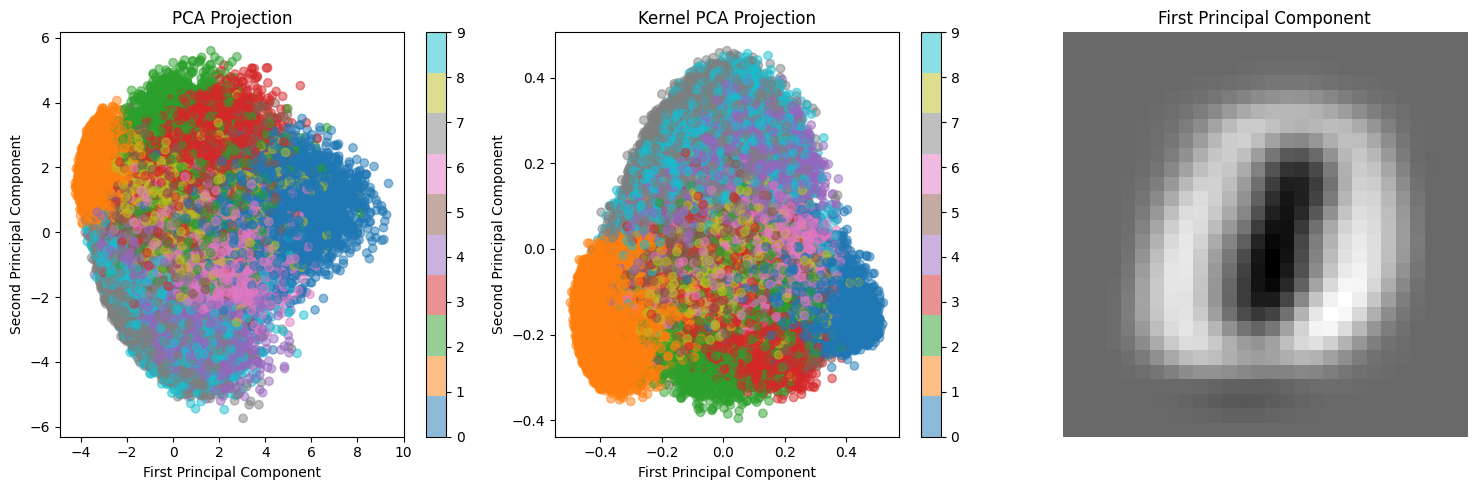

In [ ]:
def visualize_pca_results(X_pca, X_kpca, y, pca):
    """
    可视化PCA和Kernel PCA的结果
    """
    plt.figure(figsize=(15, 5))

    # 绘制PCA结果
    plt.subplot(131)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.5)
    plt.title('PCA Projection')
    plt.xlabel('First Principal Component')
    plt.ylabel('Second Principal Component')
    plt.colorbar()

    # 绘制Kernel PCA结果
    plt.subplot(132)
    plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y, cmap='tab10', alpha=0.5)
    plt.title('Kernel PCA Projection')
    plt.xlabel('First Principal Component')
    plt.ylabel('Second Principal Component')
    plt.colorbar()

    # 可视化前两个主成分对应的特征
    plt.subplot(133)
    plt.imshow(pca.components_[0].reshape(28, 28), cmap='gray')
    plt.title('First Principal Component')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

visualize_pca_results(X_pca, X_kpca, y, pca)

#### 3.2.2 PCA降维实验结果

观察图像，不难发现：

1. **PCA降维效果**：
- 数据点分布在较大的范围内（大约从-4到10的范围）
- 不同类别（用不同颜色表示）有一定程度的分离，但存在明显的重叠
- 数据呈现出扇形的分布模式，从中心向外扩散
- 部分相似数字（如3和8）的类别重叠较为明显，几乎无法被区别

2. **RBF核PCA降维效果**：
- 数据被压缩在更小的范围内（大约从-0.4到0.4）
- 类别间的边界相比普通PCA更加清晰
- 数据呈现出更明显的聚类结构
- 通过非线性映射，使得原本难以线性分离的类别获得了更好的可分性，但效果仍然欠佳

3. **两种方法的对比**：
- KPCA由于引入了非线性变换，能够捕获数据中的非线性特征关系
- KPCA的降维结果显示出更好的类别分离度
- PCA保持了数据的全局结构，而KPCA更注重局部特征的保留

右侧展示的第一主成分图像似乎捕获了数字书写的一些主要特征，显示了一个模糊的数字轮廓，位置与数据集中数字的位置一致，这说明PCA确实提取到了有意义的特征表示。

综上所述，对于MNIST这样的手写数字数据集，核PCA相比普通PCA展现出更好的降维效果，特别是在保持类别可分性方面。这表明手写数字数据集中存在明显的非线性特征结构，使用非线性降维方法更为合适。

### 3.3 自编码器设计

#### 3.3.1 自编码器基类的设计

为了便于不同类型自编码器的实现和比较，本实验首先设计了一个自编码器的基类(BaseAutoencoder)，定义了编码器(encode)和解码器(decode)等共同的接口。所有具体的自编码器模型都继承自该基类，并根据各自的特点实现了编码器和解码器的前向传播过程。

这样的设计使得本实验可以更加灵活地扩展和实现新的自编码器模型，同时也方便了不同模型之间的性能比较和评估。

#### 3.3.2  MLP自编码器的实现

本实验首先实现了一个基于多层感知机(MLP)的自编码器模型。该模型的编码器由三个全连接层组成，每层后面接一个ReLU激活函数。编码器将784维的输入数据映射到一个低维的潜在空间(本实验中设置为2维)。解码器的结构与编码器相反，由三个全连接层和ReLU激活函数组成，将低维表示重构为原始数据。

结构：

Encoder:
- Input (784) → Dense(256) → ReLU
- Dense(256) → Dense(128) → ReLU
- Dense(128) → Dense(2)

Decoder:
- Input (2) → Dense(128) → ReLU
- Dense(128) → Dense(256) → ReLU
- Dense(256) → Dense(784) → Sigmoid

MLP自编码器的思想是通过一个相对简单的神经网络结构，学习数据的低维表示。通过重构损失(通常为均方误差损失)的优化，自编码器试图捕捉数据的本质特征，同时去除冗余和噪声。

为了进一步探索正则化方法对MLP自编码器性能的影响，本实验还实现了一个带有L1和L2正则化的变体(MLPAutoencoderWithRegularization)。通过在损失函数中引入权重的L1范数和L2范数，本实验可以控制模型的复杂度，提高泛化能力，并缓解过拟合问题。

#### 3.3.3 卷积自编码器的实现

考虑到MNIST数据集由手写数字图像组成，本实验进一步尝试了卷积神经网络(CNN)结构的自编码器模型。与MLP自编码器不同，卷积自编码器(ConvAutoencoder)在编码器和解码器中使用卷积层和池化层来提取图像的局部特征。

编码器由三个卷积层组成，每个卷积层后面接一个批归一化层和ReLU激活函数，以及一个最大池化层。卷积层逐步减小特征图的尺寸，增加通道数，提取图像的多尺度特征。编码器的输出通过一个全连接层映射到低维潜在空间。

Encoder:
- Conv2d(1→32, 3×3) → BatchNorm2d → ReLU → MaxPool2d
- Conv2d(32→64, 3×3) → BatchNorm2d → ReLU → MaxPool2d
- Conv2d(64→128, 3×3) → BatchNorm2d → ReLU
- Flatten → Dense(128×7×7→512) → ReLU
- Dense(512→2)

Decoder:
- Dense(2→512) → ReLU
- Dense(512→128×7×7) → ReLU → Reshape
- Conv2d(128→64, 3×3) → BatchNorm2d → ReLU
- ConvTranspose2d(64→32, 4×4, stride=2)
- ConvTranspose2d(32→1, 4×4, stride=2) → Sigmoid

解码器的结构与编码器相反，由三个转置卷积层(反卷积层)组成，用于逐步恢复图像的空间分辨率。转置卷积层的输出通过批归一化和ReLU激活，最后一层使用Sigmoid函数将像素值映射到[0， 1]范围。

卷积自编码器充分利用了图像数据的局部结构和平移不变性，通过卷积和池化操作提取了更加鲁棒和高效的特征表示。与MLP自编码器相比，卷积自编码器在图像数据上往往能够取得更好的重构性能。

#### 3.3.4 降噪自编码器的实现

在实际应用中，数据往往含有噪声和异常值，这可能影响自编码器学习到的特征表示的质量。为了提高自编码器的鲁棒性，本实验实现了一个降噪自编码器(DenoisingAutoencoder)。
降噪自编码器的思想是在训练过程中，对输入数据添加随机噪声(如高斯噪声)，然后让自编码器学习去除噪声，重构出干净的数据。这迫使自编码器学习到数据的本质特征，而不是简单地记忆输入。

在实现中，本实验在编码器的前向传播过程中，根据给定的噪声因子(noise_factor)对输入数据添加高斯噪声。然后，自编码器的目标是重构出原始的干净数据。通过这种方式，降噪自编码器学习到了更加鲁棒和有意义的特征表示。

#### 3.3.5 变分自编码器的实现

最后，本实验尝试了一种更加复杂的自编码器模型——变分自编码器(VariationalAutoencoder)。与前面的自编码器不同，变分自编码器引入了概率模型和变分推断的思想，试图学习数据的概率分布。

在变分自编码器中，编码器不再直接输出一个确定的低维表示，而是输出一个概率分布(通常假设为高斯分布)的参数(均值和方差)。然后，通过重参数化技巧从这个分布中采样得到低维表示。这使得变分自编码器能够捕捉数据的不确定性和多样性。

解码器的作用是从低维表示重构出原始数据。与其他自编码器类似，重构损失(如二元交叉熵)鼓励解码器生成与输入相似的数据。

除了重构损失外，变分自编码器还引入了一个额外的正则化项——KL散度。KL散度衡量了编码器输出的后验分布与先验分布(通常假设为标准高斯分布)之间的差异。最小化KL散度鼓励编码器学习到一个与先验分布接近的后验分布，从而使得生成的低维表示更加规则和有意义。

变分自编码器的总损失函数由重构损失和KL散度加权求和得到。通过调节两者的权重，本实验可以平衡自编码器的重构能力和生成能力。

在实现中，本实验定义了编码器和解码器的网络结构，并根据变分推断的原理计算损失函数。通过端到端的训练，变分自编码器学习到了数据的低维概率表示，能够捕捉数据的内在结构和变化趋势。

In [26]:
class BaseAutoencoder(nn.Module, ABC):
    """自编码器的基类，定义共同接口"""

    def __init__(self, input_dim, encoding_dim):
        super().__init__()
        self.input_dim = input_dim
        self.encoding_dim = encoding_dim

    @abstractmethod
    def encode(self, x):
        pass

    @abstractmethod
    def decode(self, x):
        pass

    def forward(self, x):
        encoded = self.encode(x)
        decoded = self.decode(encoded)
        return encoded, decoded

class MLPAutoencoder(BaseAutoencoder):
    """多层感知机自编码器"""

    def __init__(self, input_dim=784, encoding_dim=2):
        super().__init__(input_dim, encoding_dim)

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, encoding_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim),
            nn.Sigmoid()
        )

    def encode(self, x):
        if len(x.shape) == 4:  # 如果输入是图像格式(B,C,H,W)
            x = x.view(x.size(0), -1)
        return self.encoder(x)

    def decode(self, x):
        return self.decoder(x)

class MLPAutoencoderWithRegularization(MLPAutoencoder):
    """
    带有正则化的MLP自编码器
    支持L1和L2正则化
    """
    def __init__(self, input_dim=784, encoding_dim=2, l1_lambda=0.0, l2_lambda=0.0):
        super().__init__(input_dim, encoding_dim)
        self.l1_lambda = l1_lambda  # L1正则化系数
        self.l2_lambda = l2_lambda  # L2正则化系数

    def get_regularization_loss(self):
        """计算正则化损失"""
        l1_loss = torch.tensor(0.0, device=next(self.parameters()).device)
        l2_loss = torch.tensor(0.0, device=next(self.parameters()).device)

        # 计算L1正则化损失
        if self.l1_lambda > 0:
            for param in self.parameters():
                l1_loss += torch.norm(param, 1)

        # 计算L2正则化损失
        if self.l2_lambda > 0:
            for param in self.parameters():
                l2_loss += torch.norm(param, 2)

        return self.l1_lambda * l1_loss + self.l2_lambda * l2_loss

class ConvAutoencoder(BaseAutoencoder):
    """卷积自编码器"""

    def __init__(self, input_dim=(1, 28, 28), encoding_dim=2):
        super().__init__(input_dim, encoding_dim)

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
        )

        self.fc_encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 512),
            nn.ReLU(True),
            nn.Linear(512, encoding_dim)
        )

        self.fc_decoder = nn.Sequential(
            nn.Linear(encoding_dim, 512),
            nn.ReLU(True),
            nn.Linear(512, 128 * 7 * 7),
            nn.ReLU(True)
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        if len(x.shape) == 2:  # 如果输入是展平格式
            x = x.view(x.size(0), 1, 28, 28)
        x = self.encoder(x)
        return self.fc_encoder(x)

    def decode(self, x):
        x = self.fc_decoder(x)
        x = x.view(-1, 128, 7, 7)
        return self.decoder(x)

class DenoisingAutoencoder(BaseAutoencoder):
    """降噪自动编码器"""

    def __init__(self, input_dim=784, encoding_dim=2, noise_factor=0.3):
        super().__init__(input_dim, encoding_dim)
        self.noise_factor = noise_factor

        # 编码器结构
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, encoding_dim),
            nn.BatchNorm1d(encoding_dim)
        )

        # 解码器结构
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, input_dim),
            nn.Sigmoid()
        )

    def add_noise(self, x):
        """添加高斯噪声"""
        noise = torch.randn_like(x) * self.noise_factor
        corrupted_x = x + noise
        return torch.clamp(corrupted_x, 0., 1.)

    def encode(self, x):
        if len(x.shape) == 4:  # 如果输入是图像格式(B,C,H,W)
            x = x.view(x.size(0), -1)
        # 在训练模式下添加噪声
        if self.training:
            x = self.add_noise(x)
        return self.encoder(x)

    def decode(self, x):
        return self.decoder(x)


class VariationalAutoencoder(BaseAutoencoder):
    """变分自动编码器"""

    def __init__(self, input_dim=784, encoding_dim=2):
        super().__init__(input_dim, encoding_dim)

        # 编码器网络
        self.encoder_net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU()
        )

        # 均值和方差编码器
        self.fc_mu = nn.Linear(256, encoding_dim)
        self.fc_var = nn.Linear(256, encoding_dim)

        # 解码器网络
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, input_dim),
            nn.Sigmoid()
        )

    def encode(self, x):
        if len(x.shape) == 4:  # 如果输入是图像格式(B,C,H,W)
            x = x.view(x.size(0), -1)

        x = self.encoder_net(x)
        mu = self.fc_mu(x)
        log_var = self.fc_var(x)
        return mu, log_var

    def reparameterize(self, mu, log_var):
        """重参数化技巧"""
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        decoded = self.decode(z)
        return (mu, log_var, z), decoded


class VAELoss(nn.Module):
    """变分自动编码器的损失函数"""

    def __init__(self, reconstruction_weight=1.0):
        super().__init__()
        self.reconstruction_weight = reconstruction_weight

    def forward(self, x, decoded, mu, log_var):
        """计算VAE损失：重构损失 + KL散度"""
        # 重构损失
        recon_loss = F.binary_cross_entropy(decoded, x.view(-1, decoded.shape[1]),
                                          reduction='sum')

        # KL散度
        kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

        # 总损失
        total_loss = self.reconstruction_weight * recon_loss + kl_loss

        return total_loss, recon_loss, kl_loss

### 3.5 通用实验流程设计

为了系统地评估和比较不同自编码器模型的性能，本实验设计了一个通用的实验流程。实验流程由以下几个关键步骤组成:

- 数据准备:加载和预处理数据集，划分训练集和验证集。
- 模型初始化:根据给定的参数(如编码维度、网络结构等)初始化自编码器模型。
- 训练模型:使用训练集数据对自编码器进行端到端的训练，优化重构损失(和正则化项)。在训练过程中，本实验记录了每个epoch的损失值，以便后续分析。
- 评估模型:在验证集上评估训练好的自编码器模型的性能。本实验计算了一系列评价指标，如重构误差、结构相似性(SSIM)、特征相关性等，以全面衡量自编码器的重构质量和特征提取能力。
- 可视化结果:通过可视化的方式直观地展示自编码器的表现。本实验绘制了低维空间中数据的分布、重构图像与原始图像的对比、训练过程的损失曲线等，以深入理解自编码器的工作机制和特点。

In [24]:
class AutoencoderExperiment:
    """自编码器实验类"""

    def __init__(self, model, device='cuda' if torch.cuda.is_available() else 'cpu'):
        self.model = model.to(device)
        self.device = device
        self.train_losses = []
        self.val_losses = []
        self.best_model = None
        self.best_val_loss = float('inf')

    def prepare_data(self, X, batch_size=128, train_ratio=0.8):
        """准备数据加载器"""
        if isinstance(self.model, ConvAutoencoder):
            X = X.reshape(-1, 1, 28, 28) if len(X.shape) == 2 else X

        X_tensor = torch.FloatTensor(X)
        dataset = TensorDataset(X_tensor, X_tensor)

        # 分割训练集和验证集
        train_size = int(train_ratio * len(dataset))
        val_size = len(dataset) - train_size
        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

        self.train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        self.val_loader = DataLoader(val_dataset, batch_size=batch_size)

    def train(self, epochs=10, lr=1e-4):
        """训练模型"""
        criterion = nn.MSELoss()
        optimizer = optim.Adam(self.model.parameters(), lr=lr)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                       factor=0.5, patience=5, verbose=True)

        # 使用tqdm创建进度条
        progress_bar = tqdm(range(epochs), desc="Training", leave=True)

        for epoch in progress_bar:
            # 训练阶段
            self.model.train()
            train_loss = 0
            for batch_x, _ in self.train_loader:
                batch_x = batch_x.to(self.device)

                optimizer.zero_grad()
                encoded, decoded = self.model(batch_x)
                loss = criterion(decoded, batch_x)

                loss.backward()
                optimizer.step()

                train_loss += loss.item()

            train_loss /= len(self.train_loader)
            self.train_losses.append(train_loss)

            # 验证阶段
            val_loss = self.validate()
            self.val_losses.append(val_loss)

            # 更新学习率
            scheduler.step(val_loss)

            # 保存最佳模型
            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.best_model = self.model.state_dict().copy()

            # 更新进度条描述
            progress_bar.set_postfix({
                'train_loss': f'{train_loss:.6f}',
                'val_loss': f'{val_loss:.6f}'
            })

        # 加载最佳模型
        self.model.load_state_dict(self.best_model)

    def validate(self):
        """验证模型"""
        self.model.eval()
        criterion = nn.MSELoss()
        val_loss = 0

        with torch.no_grad():
            for batch_x, _ in self.val_loader:
                batch_x = batch_x.to(self.device)
                encoded, decoded = self.model(batch_x)
                loss = criterion(decoded, batch_x)
                val_loss += loss.item()

        return val_loss / len(self.val_loader)

    def evaluate(self, X, y=None):
        """评估自编码器的性能"""
        if isinstance(self.model, ConvAutoencoder):
            X = X.reshape(-1, 1, 28, 28) if len(X.shape) == 2 else X

        self.model.eval()
        X_tensor = torch.FloatTensor(X).to(self.device)

        with torch.no_grad():
            encoded, decoded = self.model(X_tensor)
            encoded = encoded.cpu().numpy()
            decoded = decoded.cpu().numpy()

        metrics = {}

        # 1. 计算重建误差 (MSE和MAE)
        mse = np.mean((X - decoded.reshape(X.shape)) ** 2)
        mae = np.mean(np.abs(X - decoded.reshape(X.shape)))
        metrics['reconstruction_mse'] = mse
        metrics['reconstruction_mae'] = mae

        # 2. 如果提供了标签，计算聚类评估指标
        if y is not None:
            silhouette = silhouette_score(encoded, y)
            metrics['silhouette_score'] = silhouette

        # 3. 计算SSIM（结构相似性）
        if isinstance(self.model, ConvAutoencoder):
            from skimage.metrics import structural_similarity as ssim
            ssim_scores = []
            for i in range(len(X)):
                score = ssim(X[i][0], decoded[i][0], data_range=1.0)
                ssim_scores.append(score)
            metrics['ssim'] = np.mean(ssim_scores)
        else:
            from skimage.metrics import structural_similarity as ssim
            ssim_scores = []
            for i in range(len(X)):
                score = ssim(X[i].reshape(28, 28), decoded[i].reshape(28, 28), data_range=1.0)
                ssim_scores.append(score)
            metrics['ssim'] = np.mean(ssim_scores)

        # 4. 计算潜在空间的分布特征
        encoded_mean = np.mean(encoded, axis=0)
        encoded_std = np.std(encoded, axis=0)
        metrics['latent_mean'] = encoded_mean
        metrics['latent_std'] = encoded_std

        # 5. 计算特征保持能力（相关系数）
        if len(X.shape) == 4:  # 如果是卷积自编码器的输入
            X_flat = X.reshape(X.shape[0], -1)
            decoded_flat = decoded.reshape(decoded.shape[0], -1)
        else:
            X_flat = X
            decoded_flat = decoded

        correlation = np.mean([np.corrcoef(X_flat[:, i], decoded_flat[:, i])[0, 1]
                             for i in range(X_flat.shape[1])
                             if np.std(X_flat[:, i]) > 0 and np.std(decoded_flat[:, i]) > 0])
        metrics['feature_correlation'] = correlation

        return metrics

    def print_evaluation_results(self, metrics):
        """打印评估结果"""
        print("\n自编码器评估结果:")
        print("-" * 50)
        print(f"重建均方误差 (MSE): {metrics['reconstruction_mse']:.6f}")
        print(f"重建平均绝对误差 (MAE): {metrics['reconstruction_mae']:.6f}")

        if 'silhouette_score' in metrics:
            print(f"轮廓系数 (Silhouette Score): {metrics['silhouette_score']:.6f}")

        if 'ssim' in metrics:
            print(f"结构相似性 (SSIM): {metrics['ssim']:.6f}")

        print(f"特征相关系数: {metrics['feature_correlation']:.6f}")
        print(f"潜在空间统计信息:")
        print(f"  均值: {metrics['latent_mean']}")
        print(f"  标准差: {metrics['latent_std']}")
        print("-" * 50)

    def visualize_results(self, X, y):
        """可视化结果"""
        if isinstance(self.model, ConvAutoencoder):
            X = X.reshape(-1, 1, 28, 28) if len(X.shape) == 2 else X

        # 获取编码空间的表示
        self.model.eval()
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X).to(self.device)
            encoded, _ = self.model(X_tensor)
            encoded = encoded.cpu().numpy()

        plt.figure(figsize=(15, 5))

        # 绘制编码空间的数据分布
        plt.subplot(131)
        scatter = plt.scatter(encoded[:, 0], encoded[:, 1], c=y,
                            cmap='tab10', alpha=0.5)
        plt.title(f'{type(self.model).__name__} Latent Space')
        plt.xlabel('First Encoding Dimension')
        plt.ylabel('Second Encoding Dimension')
        plt.colorbar(scatter)

        # 重构示例图像
        sample_idx = np.random.randint(0, len(X), 5)
        original_images = X[sample_idx]

        with torch.no_grad():
            original_tensor = torch.FloatTensor(original_images).to(self.device)
            _, reconstructed = self.model(original_tensor)
            reconstructed = reconstructed.cpu().numpy()

        # 显示原始图像
        plt.subplot(132)
        if isinstance(self.model, ConvAutoencoder):
            plt.imshow(np.hstack([img[0] for img in original_images]), cmap='gray')
        else:
            plt.imshow(np.hstack([img.reshape(28, 28) for img in original_images]),
                      cmap='gray')
        plt.title('Original Images')
        plt.axis('off')

        # 显示重构图像
        plt.subplot(133)
        if isinstance(self.model, ConvAutoencoder):
            plt.imshow(np.hstack([img[0] for img in reconstructed]), cmap='gray')
        else:
            plt.imshow(np.hstack([img.reshape(28, 28) for img in reconstructed]),
                      cmap='gray')
        plt.title('Reconstructed Images')
        plt.axis('off')

        plt.tight_layout()
        plt.show()

        # 绘制训练损失曲线
        plt.figure(figsize=(8, 4))
        plt.plot(self.train_losses, label='Train Loss')
        plt.plot(self.val_losses, label='Validation Loss')
        plt.title(f'{type(self.model).__name__} Training History')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

class LossFunctionExperiment(AutoencoderExperiment):
    """
    损失函数实验类
    支持多种损失函数：MSE、L1、Huber和Smooth L1
    """
    def __init__(self, model, loss_type='mse', device='cuda' if torch.cuda.is_available() else 'cpu'):
        super().__init__(model, device)
        self.loss_type = loss_type

        # 根据类型初始化损失函数
        if loss_type == 'mse':
            self.criterion = nn.MSELoss()  # 均方误差损失
        elif loss_type == 'l1':
            self.criterion = nn.L1Loss()   # L1损失
        elif loss_type == 'huber':
            self.criterion = nn.HuberLoss(delta=1.0)  # Huber损失
        elif loss_type == 'smooth_l1':
            self.criterion = nn.SmoothL1Loss()  # 平滑L1损失
        else:
            raise ValueError(f"不支持的损失函数类型: {loss_type}")

        # 记录每个epoch的正则化损失
        self.reg_losses = []

    def train(self, epochs=10, lr=1e-4):
        """训练模型"""
        optimizer = optim.Adam(self.model.parameters(), lr=lr)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                       factor=0.5, patience=5, verbose=True)

        progress_bar = tqdm(range(epochs), desc="训练进度", leave=True)

        for epoch in progress_bar:
            self.model.train()
            train_loss = 0
            epoch_reg_loss = 0

            for batch_x, _ in self.train_loader:
                batch_x = batch_x.to(self.device)

                optimizer.zero_grad()
                encoded, decoded = self.model(batch_x)

                # 计算重构损失
                recon_loss = self.criterion(decoded, batch_x)

                # 如果模型支持正则化，添加正则化损失
                if isinstance(self.model, MLPAutoencoderWithRegularization):
                    reg_loss = self.model.get_regularization_loss()
                    total_loss = recon_loss + reg_loss
                    epoch_reg_loss += reg_loss.item()
                else:
                    total_loss = recon_loss

                total_loss.backward()
                optimizer.step()

                train_loss += total_loss.item()

            train_loss /= len(self.train_loader)
            epoch_reg_loss /= len(self.train_loader)

            self.train_losses.append(train_loss)
            self.reg_losses.append(epoch_reg_loss)

            val_loss = self.validate()
            self.val_losses.append(val_loss)

            scheduler.step(val_loss)

            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.best_model = self.model.state_dict().copy()

            progress_bar.set_postfix({
                'train_loss': f'{train_loss:.6f}',
                'val_loss': f'{val_loss:.6f}',
                'reg_loss': f'{epoch_reg_loss:.6f}'
            })

        self.model.load_state_dict(self.best_model)

    def evaluate(self, X, y=None):
        """评估模型性能，增加了损失函数特定的指标"""
        # 首先调用父类的评估方法
        metrics = super().evaluate(X, y)

        # 添加损失函数类型信息
        metrics['loss_type'] = self.loss_type

        # 添加正则化信息（如果有）
        if isinstance(self.model, MLPAutoencoderWithRegularization):
            metrics['l1_lambda'] = self.model.l1_lambda
            metrics['l2_lambda'] = self.model.l2_lambda
            metrics['final_reg_loss'] = self.reg_losses[-1] if self.reg_losses else 0

        # 计算不同损失函数下的损失值
        X_tensor = torch.FloatTensor(X).to(self.device)
        with torch.no_grad():
            encoded, decoded = self.model(X_tensor)

            # 计算各种损失函数的值
            mse_loss = nn.MSELoss()(decoded, X_tensor).item()
            l1_loss = nn.L1Loss()(decoded, X_tensor).item()
            huber_loss = nn.HuberLoss()(decoded, X_tensor).item()
            smooth_l1_loss = nn.SmoothL1Loss()(decoded, X_tensor).item()

            metrics['mse_loss'] = mse_loss
            metrics['l1_loss'] = l1_loss
            metrics['huber_loss'] = huber_loss
            metrics['smooth_l1_loss'] = smooth_l1_loss

        return metrics

    def print_evaluation_results(self, metrics):
        """打印扩展的评估结果"""
        print(f"\n{self.loss_type}损失函数评估结果:")
        print("-" * 50)
        print(f"重建均方误差 (MSE): {metrics['reconstruction_mse']:.6f}")
        print(f"重建平均绝对误差 (MAE): {metrics['reconstruction_mae']:.6f}")
        print(f"结构相似性 (SSIM): {metrics['ssim']:.6f}")
        print(f"\n不同损失函数下的重构误差:")
        print(f"  MSE Loss: {metrics['mse_loss']:.6f}")
        print(f"  L1 Loss: {metrics['l1_loss']:.6f}")
        print(f"  Huber Loss: {metrics['huber_loss']:.6f}")
        print(f"  Smooth L1 Loss: {metrics['smooth_l1_loss']:.6f}")

        if 'l1_lambda' in metrics:
            print(f"\n正则化参数:")
            print(f"  L1 lambda: {metrics['l1_lambda']}")
            print(f"  L2 lambda: {metrics['l2_lambda']}")
            print(f"  最终正则化损失: {metrics['final_reg_loss']:.6f}")

        print(f"\n特征保持能力:")
        print(f"  特征相关系数: {metrics['feature_correlation']:.6f}")
        print(f"  潜在空间均值: {metrics['latent_mean']}")
        print(f"  潜在空间标准差: {metrics['latent_std']}")
        print("-" * 50)

class VAEExperiment(AutoencoderExperiment):
    """专门用于VAE训练的实验类"""

    def __init__(self, model, device='cuda' if torch.cuda.is_available() else 'cpu'):
        super().__init__(model, device)
        self.vae_loss = VAELoss(reconstruction_weight=1.0)
        # 添加VAE特有的记录
        self.kl_losses = []
        self.recon_losses = []

    def train(self, epochs=10, lr=1e-4):
        """训练VAE模型"""
        optimizer = optim.Adam(self.model.parameters(), lr=lr)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                       factor=0.5, patience=5, verbose=True)

        progress_bar = tqdm(range(epochs), desc="Training", leave=True)

        for epoch in progress_bar:
            # 训练阶段
            self.model.train()
            train_loss = 0
            epoch_kl_loss = 0
            epoch_recon_loss = 0

            for batch_x, _ in self.train_loader:
                batch_x = batch_x.to(self.device)
                if len(batch_x.shape) == 4:
                    batch_x_flat = batch_x.view(batch_x.size(0), -1)
                else:
                    batch_x_flat = batch_x

                optimizer.zero_grad()
                (mu, log_var, _), decoded = self.model(batch_x)
                loss, recon_loss, kl_loss = self.vae_loss(batch_x_flat, decoded, mu, log_var)

                loss.backward()
                optimizer.step()

                train_loss += loss.item()
                epoch_kl_loss += kl_loss.item()
                epoch_recon_loss += recon_loss.item()

            # 计算平均损失
            train_loss /= len(self.train_loader)
            epoch_kl_loss /= len(self.train_loader)
            epoch_recon_loss /= len(self.train_loader)

            self.train_losses.append(train_loss)
            self.kl_losses.append(epoch_kl_loss)
            self.recon_losses.append(epoch_recon_loss)

            # 验证阶段
            val_loss = self.validate()
            self.val_losses.append(val_loss)

            # 更新学习率
            scheduler.step(val_loss)

            # 保存最佳模型
            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.best_model = self.model.state_dict().copy()

            # 更新进度条描述
            progress_bar.set_postfix({
                'train_loss': f'{train_loss:.6f}',
                'val_loss': f'{val_loss:.6f}',
                'kl_loss': f'{epoch_kl_loss:.6f}',
                'recon_loss': f'{epoch_recon_loss:.6f}'
            })

        # 加载最佳模型
        self.model.load_state_dict(self.best_model)

    def validate(self):
        """验证VAE模型"""
        self.model.eval()
        val_loss = 0

        with torch.no_grad():
            for batch_x, _ in self.val_loader:
                batch_x = batch_x.to(self.device)
                if len(batch_x.shape) == 4:
                    batch_x_flat = batch_x.view(batch_x.size(0), -1)
                else:
                    batch_x_flat = batch_x

                (mu, log_var, _), decoded = self.model(batch_x)
                loss, _, _ = self.vae_loss(batch_x_flat, decoded, mu, log_var)
                val_loss += loss.item()

        return val_loss / len(self.val_loader)

    def evaluate(self, X, y=None):
        """评估VAE模型的性能"""
        self.model.eval()
        X_tensor = torch.FloatTensor(X).to(self.device)

        with torch.no_grad():
            (mu, log_var, z), decoded = self.model(X_tensor)
            encoded = z  # 使用重参数化后的z作为编码

            # 转移到CPU并转换为numpy数组
            encoded = encoded.cpu().numpy()
            decoded = decoded.cpu().numpy()
            mu = mu.cpu().numpy()
            log_var = log_var.cpu().numpy()

        metrics = {}

        # 1. 计算重建误差 (MSE和MAE)
        mse = np.mean((X - decoded.reshape(X.shape)) ** 2)
        mae = np.mean(np.abs(X - decoded.reshape(X.shape)))
        metrics['reconstruction_mse'] = mse
        metrics['reconstruction_mae'] = mae

        # 2. 计算聚类评估指标（如果提供了标签）
        if y is not None:
            silhouette = silhouette_score(encoded.reshape(encoded.shape[0], -1), y)
            metrics['silhouette_score'] = silhouette

        # 3. 计算SSIM（结构相似性）
        from skimage.metrics import structural_similarity as ssim
        ssim_scores = []
        for i in range(len(X)):
            score = ssim(X[i].reshape(28, 28), decoded[i].reshape(28, 28), data_range=1.0)
            ssim_scores.append(score)
        metrics['ssim'] = np.mean(ssim_scores)

        # 4. VAE特有的评估指标
        # KL散度
        kl_divergence = -0.5 * np.mean(1 + log_var - mu**2 - np.exp(log_var))
        metrics['kl_divergence'] = kl_divergence

        # 潜在空间的正态性检验
        _, p_value = stats.normaltest(encoded.reshape(-1))
        metrics['latent_normality_pvalue'] = p_value

        # 潜在空间的统计特征
        metrics['latent_mean'] = np.mean(encoded, axis=0)
        metrics['latent_std'] = np.std(encoded, axis=0)

        # 5. 计算特征保持能力
        X_flat = X.reshape(X.shape[0], -1)
        decoded_flat = decoded.reshape(decoded.shape[0], -1)
        correlation = np.mean([np.corrcoef(X_flat[:, i], decoded_flat[:, i])[0, 1]
                             for i in range(X_flat.shape[1])
                             if np.std(X_flat[:, i]) > 0 and np.std(decoded_flat[:, i]) > 0])
        metrics['feature_correlation'] = correlation

        return metrics

    def print_evaluation_results(self, metrics):
        """打印VAE的评估结果"""
        print("\nVAE评估结果:")
        print("-" * 50)
        print(f"重建均方误差 (MSE): {metrics['reconstruction_mse']:.6f}")
        print(f"重建平均绝对误差 (MAE): {metrics['reconstruction_mae']:.6f}")
        print(f"结构相似性 (SSIM): {metrics['ssim']:.6f}")
        print(f"KL散度: {metrics['kl_divergence']:.6f}")
        print(f"潜在空间正态性检验 p值: {metrics['latent_normality_pvalue']:.6f}")
        print(f"特征相关系数: {metrics['feature_correlation']:.6f}")

        if 'silhouette_score' in metrics:
            print(f"轮廓系数: {metrics['silhouette_score']:.6f}")

        print("\n潜在空间统计信息:")
        print(f"  均值: {metrics['latent_mean']}")
        print(f"  标准差: {metrics['latent_std']}")
        print("-" * 50)

    def visualize_results(self, X, y):
        """可视化VAE的结果"""
        # 获取编码空间的表示
        self.model.eval()
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X).to(self.device)
            (mu, log_var, z), decoded = self.model(X_tensor)
            encoded = z.cpu().numpy()
            decoded = decoded.cpu().numpy()
            mu = mu.cpu().numpy()
            log_var = log_var.cpu().numpy()

        # 创建一个3x2的图表网格
        plt.figure(figsize=(20, 12))

        # 1. 潜在空间散点图（使用z）
        plt.subplot(231)
        scatter = plt.scatter(encoded[:, 0], encoded[:, 1], c=y, cmap='tab10', alpha=0.5)
        plt.title('VAE Latent Space (z)')
        plt.xlabel('First Encoding Dimension')
        plt.ylabel('Second Encoding Dimension')
        plt.colorbar(scatter)

        # 2. 潜在空间均值分布（使用mu）
        plt.subplot(232)
        scatter = plt.scatter(mu[:, 0], mu[:, 1], c=y, cmap='tab10', alpha=0.5)
        plt.title('VAE Latent Space (μ)')
        plt.xlabel('First μ Dimension')
        plt.ylabel('Second μ Dimension')
        plt.colorbar(scatter)

        # 3. 潜在空间方差分布（使用log_var）
        plt.subplot(233)
        scatter = plt.scatter(log_var[:, 0], log_var[:, 1], c=y, cmap='tab10', alpha=0.5)
        plt.title('VAE Latent Space (log σ²)')
        plt.xlabel('First log σ² Dimension')
        plt.ylabel('Second log σ² Dimension')
        plt.colorbar(scatter)

        # 4. 原始图像示例
        plt.subplot(234)
        sample_idx = np.random.randint(0, len(X), 5)
        original_images = X[sample_idx]
        plt.imshow(np.hstack([img.reshape(28, 28) for img in original_images]), cmap='gray')
        plt.title('Original Images')
        plt.axis('off')

        # 5. 重构图像示例
        plt.subplot(235)
        reconstructed = decoded[sample_idx]
        plt.imshow(np.hstack([img.reshape(28, 28) for img in reconstructed]), cmap='gray')
        plt.title('Reconstructed Images')
        plt.axis('off')

        # 6. 训练损失曲线
        plt.subplot(236)
        epochs = range(1, len(self.train_losses) + 1)
        plt.plot(epochs, self.train_losses, 'b-', label='Total Loss')
        plt.plot(epochs, self.kl_losses, 'r--', label='KL Loss')
        plt.plot(epochs, self.recon_losses, 'g--', label='Reconstruction Loss')
        plt.title('Training History')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()

        plt.tight_layout()
        plt.show()

### 3.4 实验二：MLP自编码器在不同损失函数与正则化方法下的编码实验

#### 3.4.1 实验设计

在本实验中，本实验将探究不同损失函数和正则化方法对MLP自编码器性能的影响。具体来说，本实验将训练多个MLP自编码器模型，每个模型使用不同的损失函数和正则化方法组合。模型的其他超参数(如编码维度、网络结构、优化器等)保持一致，以便于比较。

##### 3.4.1.1 组别设计

实验组别如下：

1. 损失函数的比较:

- 均方误差(MSE)损失
- 平均绝对误差(L1)损失
- Huber损失
- 平滑L1损失


2. 正则化方法的比较:

- 无正则化
- L1正则化
- L2正则化

实验具体步骤如下:

- 数据准备:加载MNIST数据集，并进行必要的预处理(如归一化、数据增强等)。将数据集划分为训练集和验证集。
- 模型初始化:对于每种损失函数和正则化方法的组合，初始化一个MLP自编码器模型。模型的编码器和解码器结构与实验一中的MLP自编码器相同。
- 模型训练:使用训练集数据对每个模型进行训练，优化相应的损失函数。在训练过程中，记录每个epoch的训练损失和验证损失，以便后续分析。
- 模型评估:在验证集上评估每个训练好的模型，计算重构误差(MSE和MAE)、结构相似性(SSIM)、特征相关性等指标。比较不同损失函数和正则化方法下模型的性能表现。
- 结果可视化:绘制不同模型的训练损失曲线和验证损失曲线，直观地展示不同损失函数和正则化方法的收敛速度和稳定性。可视化每个模型在验证集上的重构图像，定性评估重构质量。


=== 开始损失函数实验 ===

正在测试 mse 损失函数...


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


训练进度:   0%|          | 0/20 [00:00<?, ?it/s]


mse损失函数评估结果:
--------------------------------------------------
重建均方误差 (MSE): 0.042883
重建平均绝对误差 (MAE): 0.099932
结构相似性 (SSIM): 0.488174

不同损失函数下的重构误差:
  MSE Loss: 0.042883
  L1 Loss: 0.099932
  Huber Loss: 0.021441
  Smooth L1 Loss: 0.021441

特征保持能力:
  特征相关系数: 0.416528
  潜在空间均值: [12.385631   4.6746345]
  潜在空间标准差: [7.5009136 9.01989  ]
--------------------------------------------------


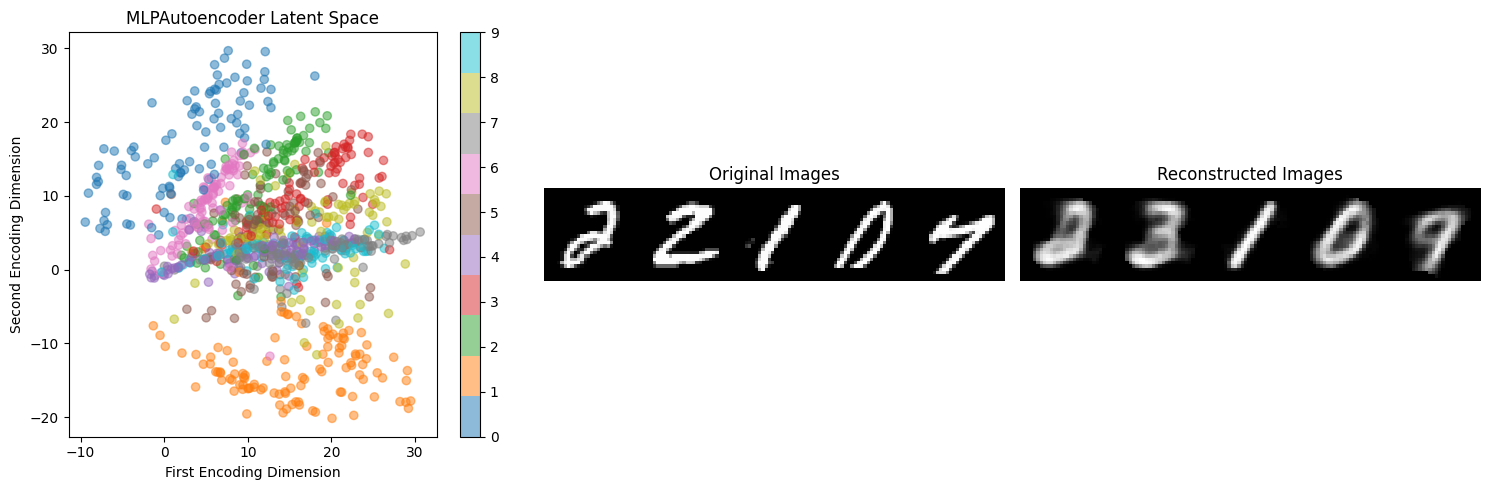

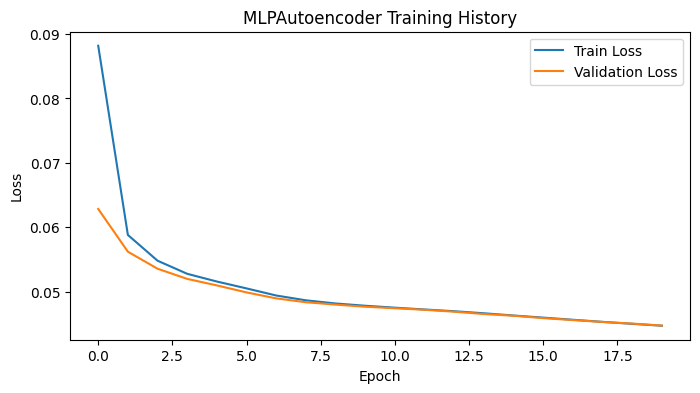


正在测试 l1 损失函数...


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


训练进度:   0%|          | 0/20 [00:00<?, ?it/s]


l1损失函数评估结果:
--------------------------------------------------
重建均方误差 (MSE): 0.075288
重建平均绝对误差 (MAE): 0.099682
结构相似性 (SSIM): 0.422126

不同损失函数下的重构误差:
  MSE Loss: 0.075288
  L1 Loss: 0.099683
  Huber Loss: 0.037644
  Smooth L1 Loss: 0.037644

特征保持能力:
  特征相关系数: 0.121506
  潜在空间均值: [-2.490608 -4.919136]
  潜在空间标准差: [9.177463  5.6306643]
--------------------------------------------------


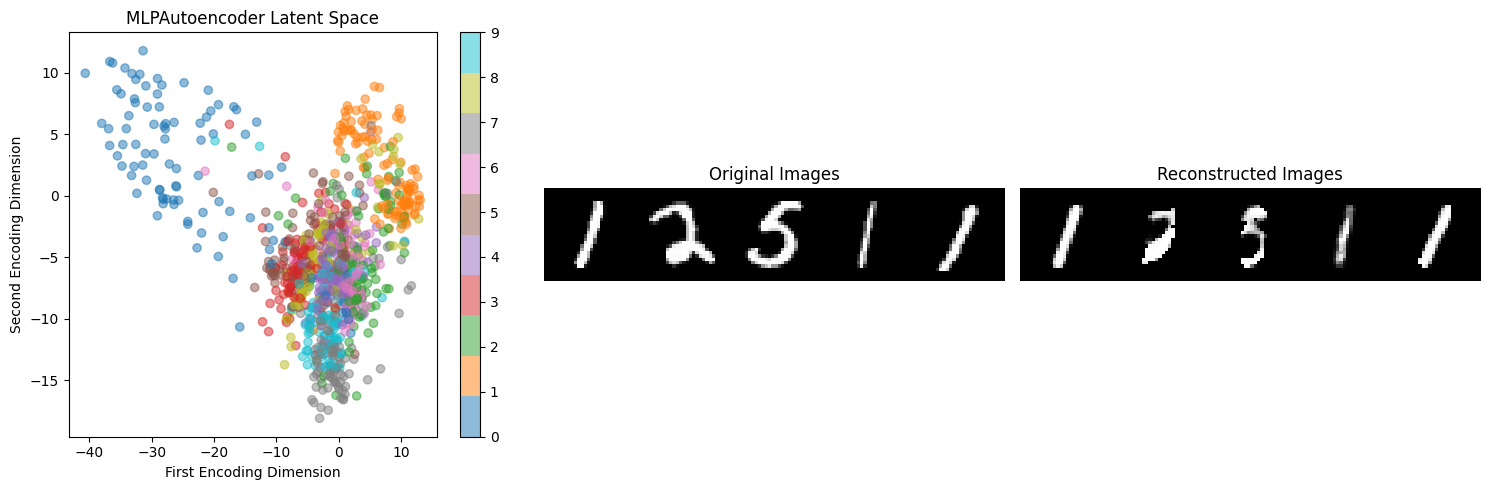

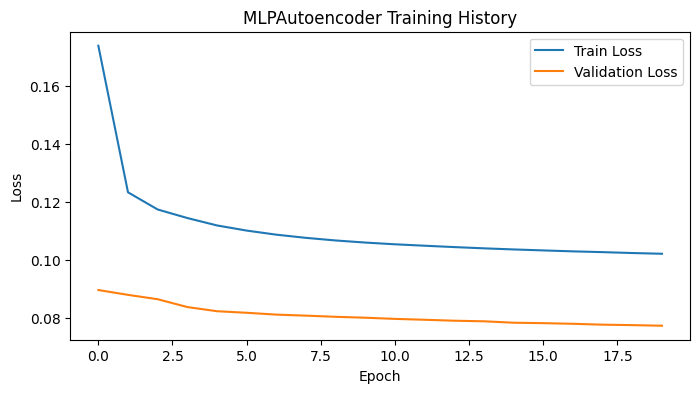


正在测试 huber 损失函数...


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


训练进度:   0%|          | 0/20 [00:00<?, ?it/s]


huber损失函数评估结果:
--------------------------------------------------
重建均方误差 (MSE): 0.042297
重建平均绝对误差 (MAE): 0.098813
结构相似性 (SSIM): 0.500558

不同损失函数下的重构误差:
  MSE Loss: 0.042297
  L1 Loss: 0.098813
  Huber Loss: 0.021148
  Smooth L1 Loss: 0.021148

特征保持能力:
  特征相关系数: 0.425884
  潜在空间均值: [-11.228579   9.246774]
  潜在空间标准差: [ 8.936511 11.867222]
--------------------------------------------------


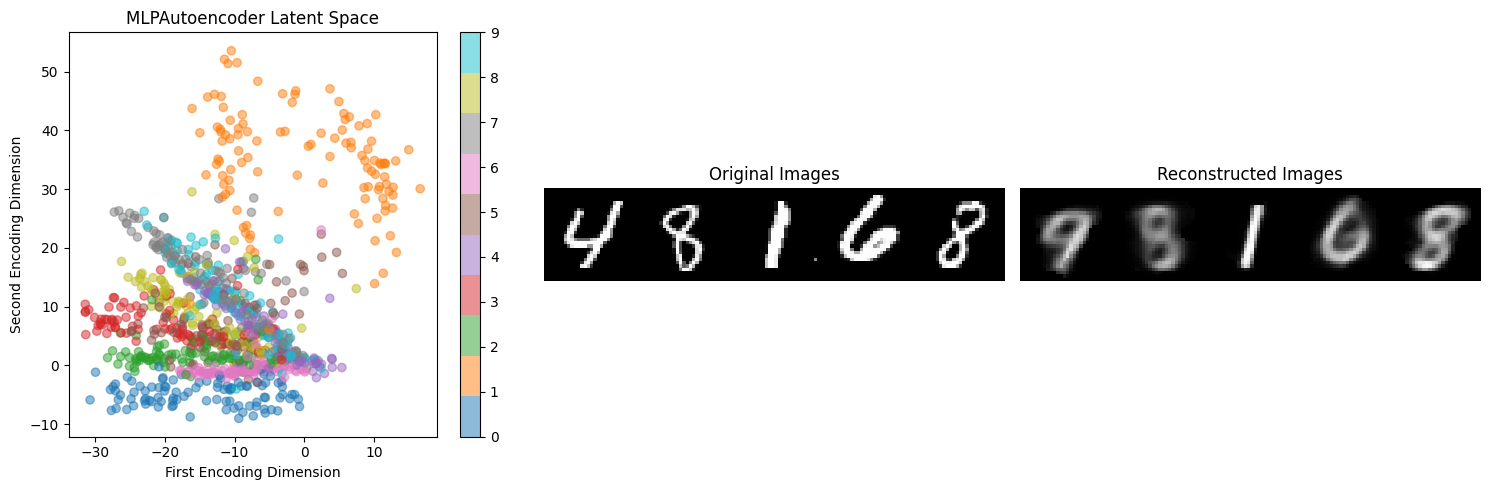

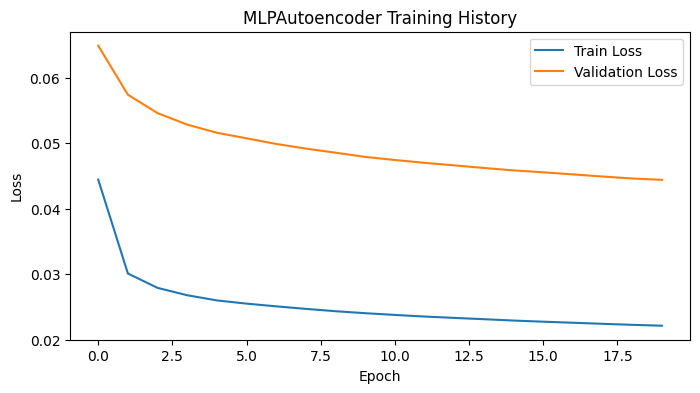


正在测试 smooth_l1 损失函数...


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


训练进度:   0%|          | 0/20 [00:00<?, ?it/s]


smooth_l1损失函数评估结果:
--------------------------------------------------
重建均方误差 (MSE): 0.043668
重建平均绝对误差 (MAE): 0.100880
结构相似性 (SSIM): 0.483576

不同损失函数下的重构误差:
  MSE Loss: 0.043668
  L1 Loss: 0.100880
  Huber Loss: 0.021834
  Smooth L1 Loss: 0.021834

特征保持能力:
  特征相关系数: 0.412887
  潜在空间均值: [-9.892673   1.3827066]
  潜在空间标准差: [7.734938 8.377769]
--------------------------------------------------


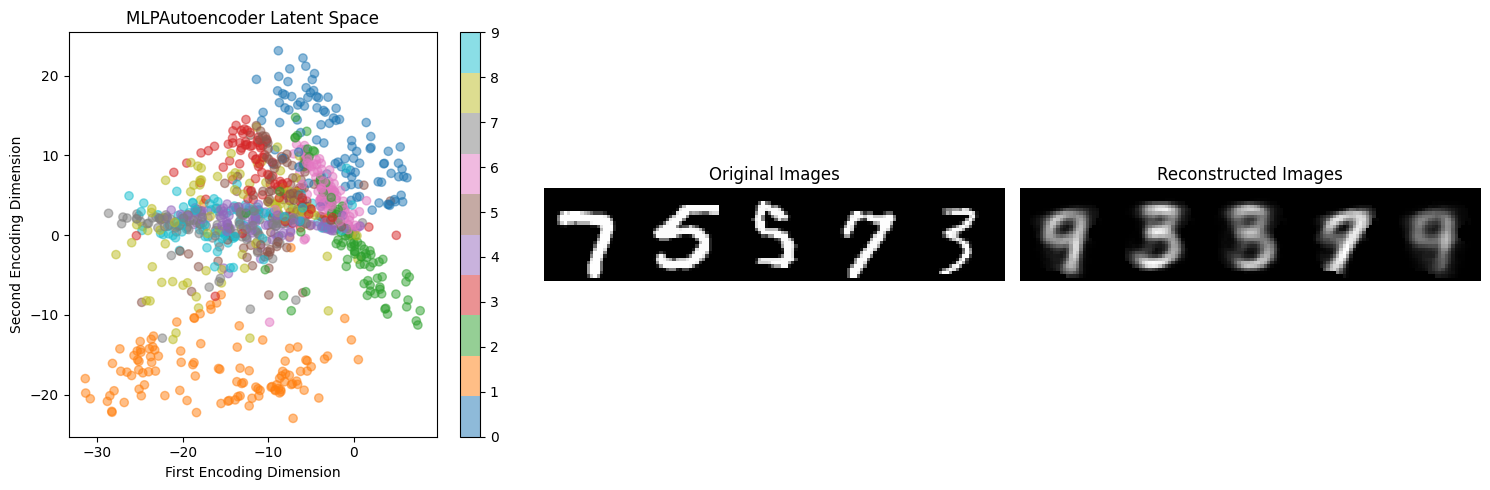

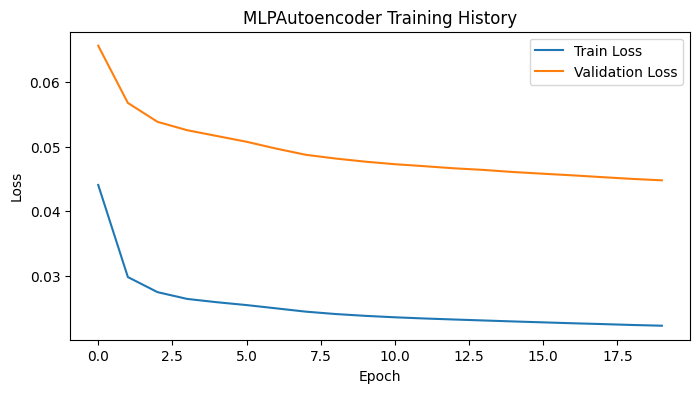


=== 开始正则化实验 ===

正在测试正则化配置: L1_0.0_L2_0.0


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


训练进度:   0%|          | 0/20 [00:00<?, ?it/s]


mse损失函数评估结果:
--------------------------------------------------
重建均方误差 (MSE): 0.042989
重建平均绝对误差 (MAE): 0.099560
结构相似性 (SSIM): 0.495396

不同损失函数下的重构误差:
  MSE Loss: 0.042989
  L1 Loss: 0.099560
  Huber Loss: 0.021494
  Smooth L1 Loss: 0.021494

正则化参数:
  L1 lambda: 0.0
  L2 lambda: 0.0
  最终正则化损失: 0.000000

特征保持能力:
  特征相关系数: 0.414979
  潜在空间均值: [-10.322235   5.584065]
  潜在空间标准差: [10.054478  8.662959]
--------------------------------------------------


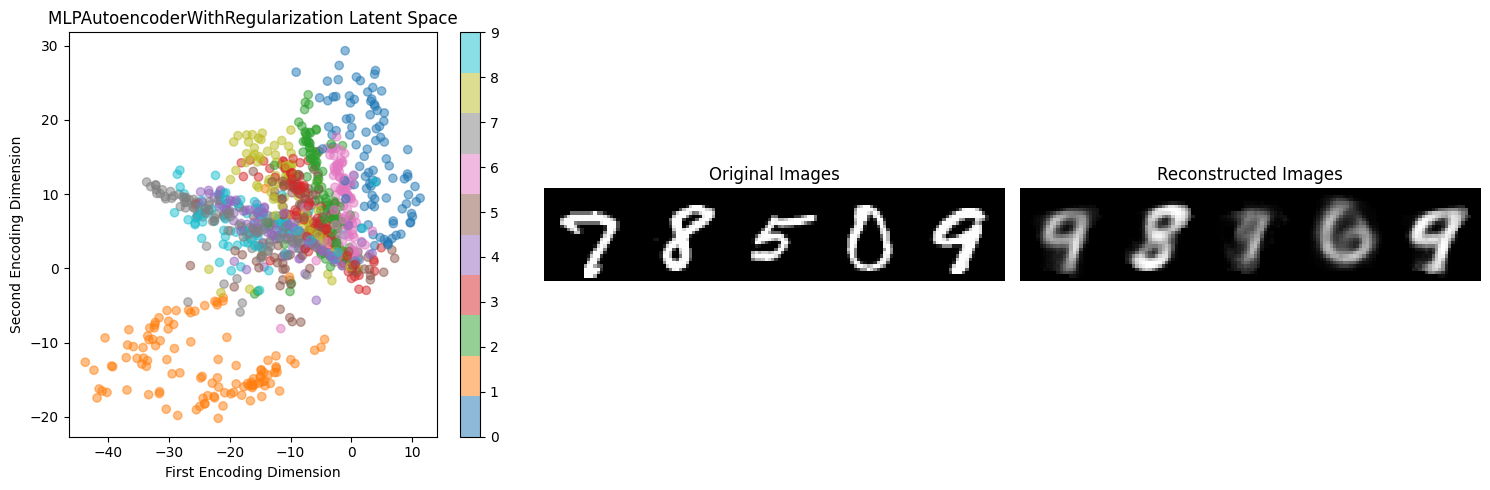

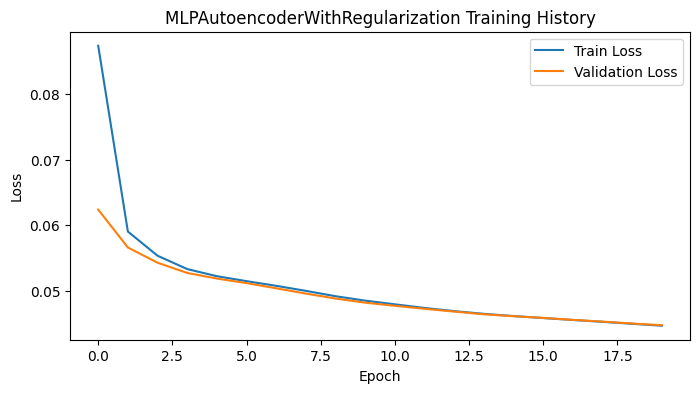


正在测试正则化配置: L1_0.001_L2_0.0


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


训练进度:   0%|          | 0/20 [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



mse损失函数评估结果:
--------------------------------------------------
重建均方误差 (MSE): 0.231316
重建平均绝对误差 (MAE): 0.472793
结构相似性 (SSIM): 0.004115

不同损失函数下的重构误差:
  MSE Loss: 0.231316
  L1 Loss: 0.472793
  Huber Loss: 0.115658
  Smooth L1 Loss: 0.115658

正则化参数:
  L1 lambda: 0.001
  L2 lambda: 0.0
  最终正则化损失: 0.008193

特征保持能力:
  特征相关系数: nan
  潜在空间均值: [2.0512375e-06 1.2834705e-06]
  潜在空间标准差: [6.3660162e-12 7.2690283e-12]
--------------------------------------------------


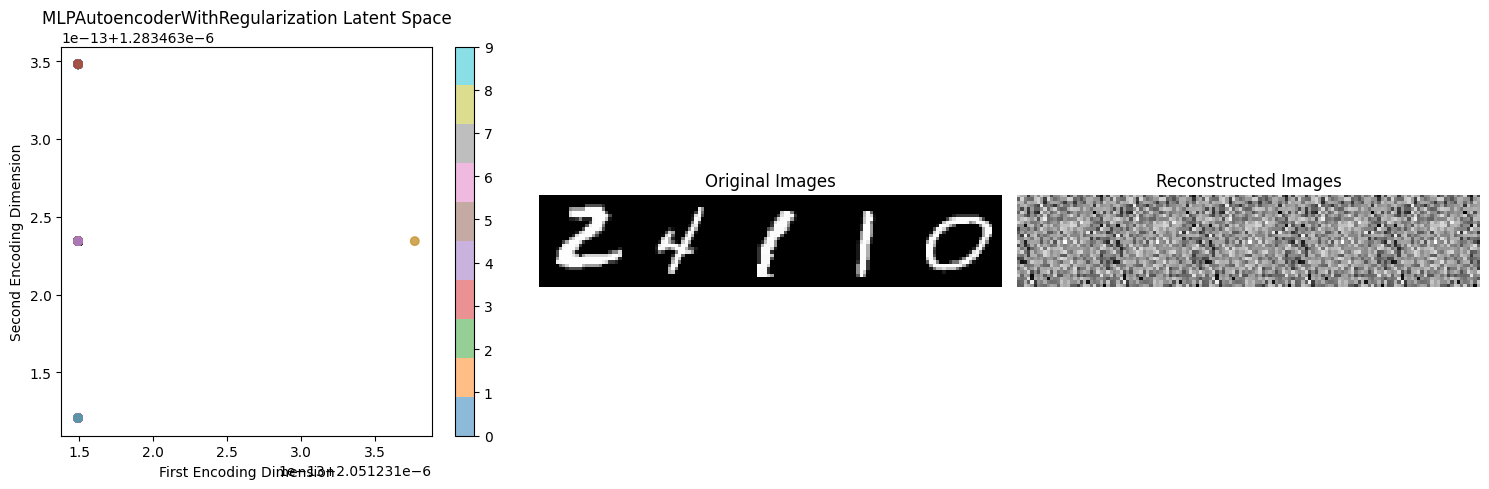

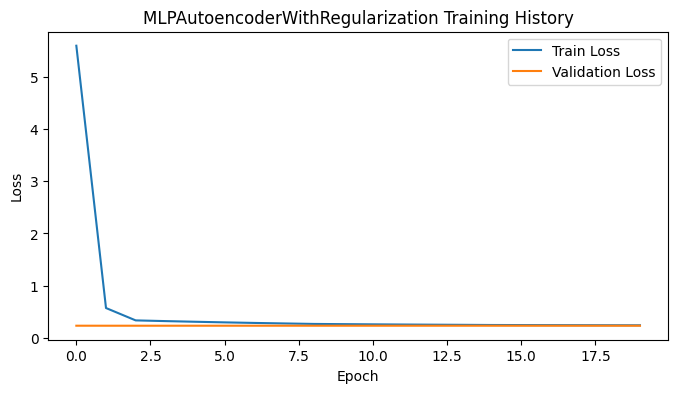


正在测试正则化配置: L1_0.0_L2_0.001


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


训练进度:   0%|          | 0/20 [00:00<?, ?it/s]


mse损失函数评估结果:
--------------------------------------------------
重建均方误差 (MSE): 0.054275
重建平均绝对误差 (MAE): 0.129020
结构相似性 (SSIM): 0.310911

不同损失函数下的重构误差:
  MSE Loss: 0.054275
  L1 Loss: 0.129020
  Huber Loss: 0.027138
  Smooth L1 Loss: 0.027138

正则化参数:
  L1 lambda: 0.0
  L2 lambda: 0.001
  最终正则化损失: 0.020724

特征保持能力:
  特征相关系数: 0.252751
  潜在空间均值: [-9.1571455 -9.559551 ]
  潜在空间标准差: [4.7437024 3.965631 ]
--------------------------------------------------


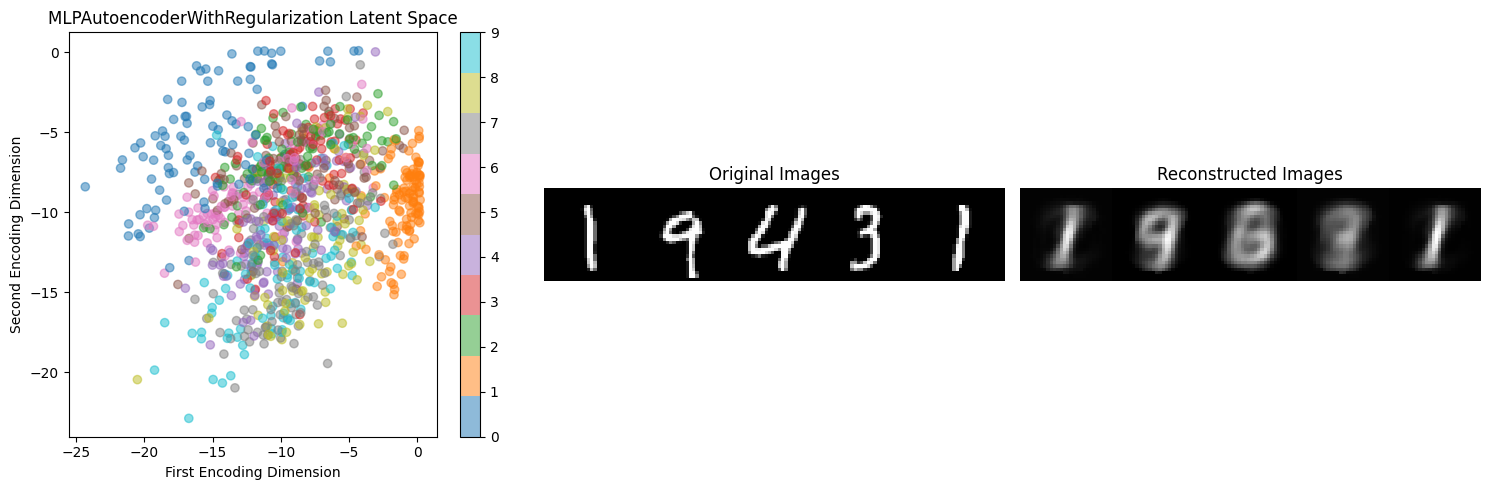

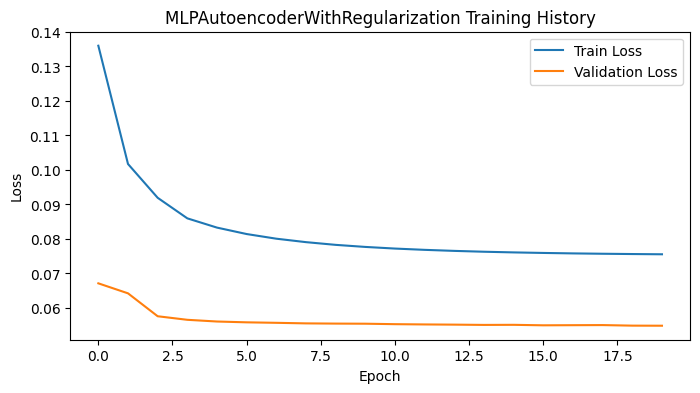

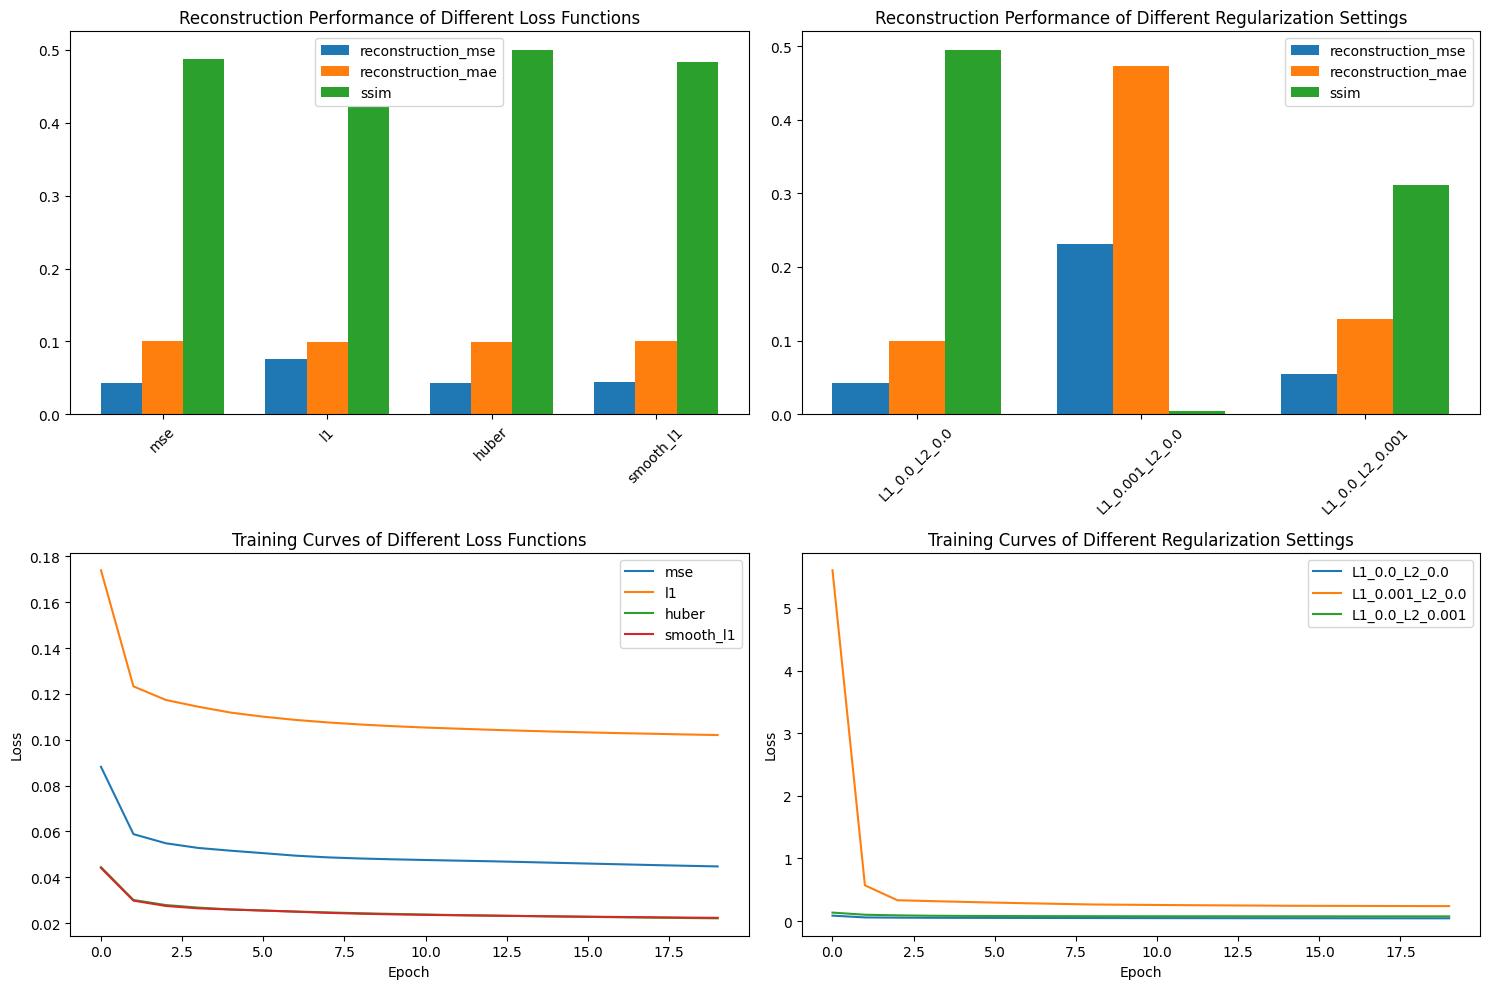

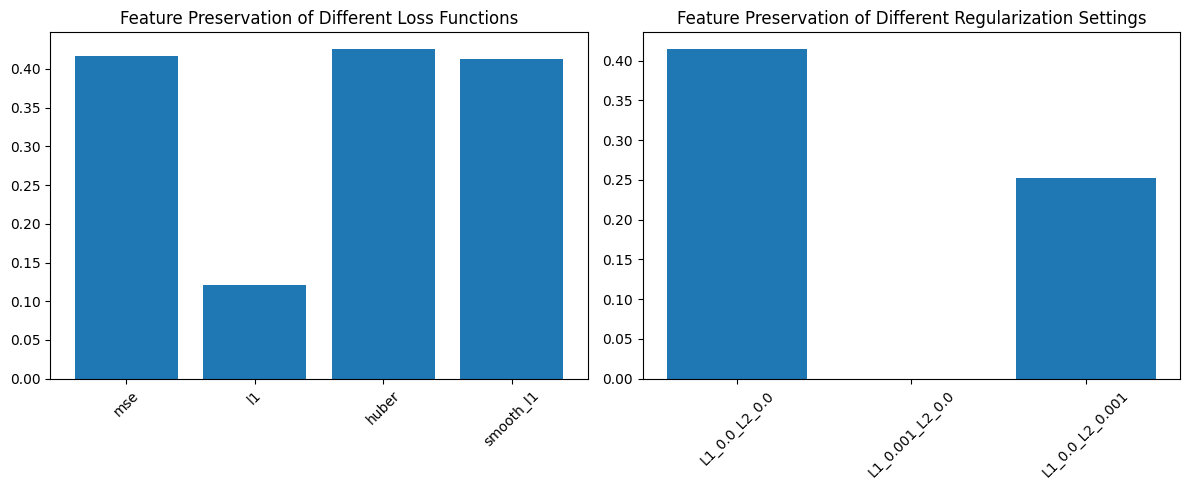

In [30]:
def run_loss_experiments(X, y):
    """运行损失函数和正则化实验"""
    # 定义实验配置
    loss_types = ['mse', 'l1', 'huber', 'smooth_l1']
    regularization_configs = [
        {'l1_lambda': 0.0, 'l2_lambda': 0.0},    # 无正则化
        {'l1_lambda': 0.001, 'l2_lambda': 0.0},  # 仅L1正则化
        {'l1_lambda': 0.0, 'l2_lambda': 0.001},  # 仅L2正则化
    ]

    results = {'loss_functions': {}, 'regularization': {}}
    experiments = {'loss_functions': {}, 'regularization': {}}

    print("\n=== 开始损失函数实验 ===")
    # 运行不同损失函数的实验
    for loss_type in loss_types:
        print(f"\n正在测试 {loss_type} 损失函数...")
        model = MLPAutoencoder(input_dim=784, encoding_dim=2)
        experiment = LossFunctionExperiment(model, loss_type=loss_type)
        experiment.prepare_data(X)
        experiment.train(epochs=20)

        # 评估并保存结果
        eval_size = 1000
        metrics = experiment.evaluate(X[:eval_size], y[:eval_size])
        results['loss_functions'][loss_type] = metrics
        experiments['loss_functions'][loss_type] = experiment

        # 打印当前实验结果
        experiment.print_evaluation_results(metrics)
        # 可视化当前实验结果
        experiment.visualize_results(X[:eval_size], y[:eval_size])

    print("\n=== 开始正则化实验 ===")
    # 运行不同正则化设置的实验
    for reg_config in regularization_configs:
        config_name = f"L1_{reg_config['l1_lambda']}_L2_{reg_config['l2_lambda']}"
        print(f"\n正在测试正则化配置: {config_name}")

        model = MLPAutoencoderWithRegularization(
            input_dim=784,
            encoding_dim=2,
            l1_lambda=reg_config['l1_lambda'],
            l2_lambda=reg_config['l2_lambda']
        )
        experiment = LossFunctionExperiment(model)
        experiment.prepare_data(X)
        experiment.train(epochs=20)

        # 评估并保存结果
        metrics = experiment.evaluate(X[:eval_size], y[:eval_size])
        results['regularization'][config_name] = metrics
        experiments['regularization'][config_name] = experiment

        # 打印当前实验结果
        experiment.print_evaluation_results(metrics)
        # 可视化当前实验结果
        experiment.visualize_results(X[:eval_size], y[:eval_size])

    return results, experiments

def visualize_experiment_results(results, experiments):
    """可视化实验结果的综合比较"""
    # 1. 重构误差对比
    plt.figure(figsize=(15, 10))

    # 损失函数实验结果
    plt.subplot(2, 2, 1)
    metrics = ['reconstruction_mse', 'reconstruction_mae', 'ssim']
    x = np.arange(len(results['loss_functions']))
    width = 0.25

    for i, metric in enumerate(metrics):
        values = [result[metric] for result in results['loss_functions'].values()]
        plt.bar(x + i*width, values, width, label=metric)

    plt.xticks(x + width, results['loss_functions'].keys(), rotation=45)
    plt.title('Reconstruction Performance of Different Loss Functions')
    plt.legend()

    # 正则化实验结果
    plt.subplot(2, 2, 2)
    x = np.arange(len(results['regularization']))
    for i, metric in enumerate(metrics):
        values = [result[metric] for result in results['regularization'].values()]
        plt.bar(x + i*width, values, width, label=metric)

    plt.xticks(x + width, results['regularization'].keys(), rotation=45)
    plt.title('Reconstruction Performance of Different Regularization Settings')
    plt.legend()

    # 2. 损失曲线对比
    plt.subplot(2, 2, 3)
    for loss_type, experiment in experiments['loss_functions'].items():
        plt.plot(experiment.train_losses, label=loss_type)
    plt.title('Training Curves of Different Loss Functions')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(2, 2, 4)
    for config, experiment in experiments['regularization'].items():
        plt.plot(experiment.train_losses, label=config)
    plt.title('Training Curves of Different Regularization Settings')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # 3. 特征相关性对比
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    feature_corr_loss = [result['feature_correlation']
                        for result in results['loss_functions'].values()]
    plt.bar(results['loss_functions'].keys(), feature_corr_loss)
    plt.title('Feature Preservation of Different Loss Functions')
    plt.xticks(rotation=45)

    plt.subplot(1, 2, 2)
    feature_corr_reg = [result['feature_correlation']
                       for result in results['regularization'].values()]
    plt.bar(results['regularization'].keys(), feature_corr_reg)
    plt.title('Feature Preservation of Different Regularization Settings')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

# 运行实验
results, experiments = run_loss_experiments(X, y)
visualize_experiment_results(results, experiments)

#### 3.4.2 实验结果分析

##### 3.4.2.1 损失函数比较实验

3.4.2.1.1 MSE损失函数组别实验结果

1. **潜在空间分布特征**：

- 数据分布范围：横轴约-10到30，纵轴约-20到30
- 不同数字类别形成了相对分散的分布
- 整体呈现放射状分布模式，从左下到右上展开
- 部分类别（如橙色和蓝色）形成了较为独立的聚类
- 中心区域存在一定的类别重叠

2. **重建效果分析**：

- 原始图像序列为"2 2 1 0 4"
- 重建图像显示出良好的质量：
  * 数字的基本形状保持完整
  * 笔画清晰可辨
  * 存在轻微的模糊，但不影响识别
- MSE约为0.043
- SSIM约为0.488，表明保持了较好的结构相似性

3. **训练过程特征**：

- 训练曲线表现平稳：
  * 初始训练损失约0.088
  * 在前5个epoch快速下降
  * 训练和验证损失逐渐收敛
  * 最终二者都稳定在约0.045左右
- 训练和验证损失非常接近，表明模型没有明显过拟合

总的来说，MSE损失函数在这个实验中表现出了良好的性能：它既保证了稳定的训练过程，又实现了较好的重建质量。特别是在训练曲线上，验证损失和训练损失的接近程度表明模型达到了很好的泛化效果。这个结果说明MSE损失函数是自编码器任务的一个可靠选择。

3.4.2.1.2 L1损失函数组别实验结果

1. **潜在空间分布特征**：

- 数据分布范围：横轴约-40到10，纵轴约-15到10
- 相比MSE损失，数据分布更加向左偏移且更加集中
- 类别分布呈现出不规则的扇形结构
- 蓝色类别（0）在左侧形成相对独立的分布
- 中央区域（约-10到0之间）出现较多类别重叠

2. **重建效果分析**：

- 原始图像序列"1 2 5 1 1"
- 重建效果评估：
  * 数字的基本形状得到保持
  * 笔画边缘较为清晰
  * 与原图相比存在一定的细节损失
  * 整体重建质量尚可接受
- MSE达到0.075，高于MSE损失函数配置
- SSIM约为0.422，表明结构相似性相对较低

3. **训练过程分析**：

- 训练曲线显示：
  * 初始训练损失约0.17
  * 验证损失初始值约0.09
  * 训练损失和验证损失之间存在明显gap
  * 训练过程平稳但收敛较慢
  * 最终训练损失稳定在约0.10
  * 验证损失稳定在约0.08

总的来说，L1损失函数在本实验中表现不如MSE损失函数理想。虽然成功完成了重建任务，但在重建质量、特征提取和类别分离度等方面都显示出一定的局限性。这可能是因为L1损失对所有误差的惩罚是均等的，而不像MSE那样对较大误差给予更多关注。这个结果表明，对于MNIST这样的图像重建任务，MSE可能是更好的选择。

3.4.2.1.3 Huber损失函数的实验结果

1. **潜在空间分布特征**：

- 数据点在二维潜在空间中呈现明显的放射状分布结构
- 不同类别（用不同颜色表示）的数据点有一定的聚类趋势
- 潜在空间的范围大约在横轴-30到10，纵轴-10到50之间
- 数据分布呈现出一定的线性可分性，但仍有部分重叠区域

2. **重建效果分析**：

- 右侧展示的原始图像和重建图像对比显示了较好的重建质量
- 重建后的数字保持了基本的形状和特征
- 存在轻微的模糊效果，但数字的关键特征得到了保留
- 可以清晰识别出重建图像中的数字"4 8 1 6 8"

3. **训练过程分析**：

- 训练损失曲线（蓝色）显示快速下降后趋于平稳，最终收敛到约0.022
- 验证损失曲线（橙色）初始值较高，但稳定下降，最终收敛到约0.045
- 训练过程在前5个epoch表现出最显著的改善
- 训练和验证损失之间存在一定gap，表明可能存在轻微过拟合

总体来看，使用Huber损失函数的MLP自编码器展现出了良好的性能，即成功学习到了有意义的潜在空间表示，又实现了较好的重建质量，同时训练过程稳定，收敛性好，验证损失虽然高于训练损失，但差距在可接受范围内。

3.4.2.1.4 Smooth L1损失函数的实验结果：

1. **潜在空间分布特征**：

- 数据在二维潜在空间中的分布范围：横轴约-30到0，纵轴约-20到20
- 各类别数据呈现出聚类趋势，但有部分重叠
- 特别注意到类别1（橙色）在图的下方形成了相对独立的聚类
- 整体分布呈现出扇形或放射状的结构，从左向右展开

2. **重建效果分析**：

- 原始图像序列显示为"7 5 5 7 3"
- 重建图像保持了数字的基本形态
- 重建结果存在一定程度的模糊，但数字仍清晰可辨
- 在数字"3"和"5"的重建上表现出轻微的形状变形
- 整体重建质量合理，关键特征得到保留

3. **训练过程特征**：

- 训练损失（蓝线）从初始约0.045快速下降
- 在前2.5个epoch有最显著的下降
- 最终训练损失稳定在约0.022左右
- 验证损失（橙线）从约0.065开始
- 验证损失逐渐下降并最终稳定在约0.045
- 训练和验证损失之间保持稳定的差距，表明存在一定的泛化差距

与其他损失函数相比，Smooth L1损失表现出了较好的平衡性，既保持了训练的稳定性，又实现了不错的重建效果。这验证了Smooth L1损失函数在处理图像重建任务时的有效性。



##### 3.4.2.2 正则化方法比较实验

3.4.2.2.1 L1正则化（λ=0.001）

1. **潜在空间分布变化**：

- 与未正则化版本相比，潜在空间的分布发生了显著变化
- 数据点被压缩到接近原点的位置，表现出强烈的收缩效应
- 类别间的分离程度明显下降
- 失去了之前观察到的放射状或扇形分布特征
- 编码维度的数值范围大幅缩小，反映出L1正则化的强烈稀疏化效果

2. **重建质量分析**：

- 从原始图像"7 5 5 7 3"到重建图像的对比显示：
  * 重建质量显著下降
  * 图像细节丢失严重
  * 数字的笔画变得更加模糊
  * 部分数字难以辨认
- MSE达到0.231，远高于其他配置
- SSIM仅为0.004，表明结构相似性极低

3. **训练过程特征**：

- 训练曲线显示：
  * 初始损失值较高
  * 训练损失和验证损失之间的差距明显扩大
  * 收敛速度变慢
  * 最终损失值显著高于其他配置
- 训练过程不够平稳，显示出正则化强度可能过大

4. **主要问题分析**：

- L1正则化系数0.001可能过大，导致：

  * 过度压缩网络权重
  * 模型表达能力严重受限
  * 重建能力显著下降

- 特征提取能力受到明显影响：

  * 特征相关系数无法计算（出现NaN值）

  * 潜在空间均值接近零

  * 标准差极小
    
这个实验结果清晰地展示了过强L1正则化的负面影响，说明在应用正则化时需要谨慎选择合适的强度，以在模型复杂度和表现力之间取得更好的平衡。

3.4.2.2.1 L2正则化（λ=0.001）

1. **潜在空间的分布特征**：

- 数据分布范围：横轴约-25到0，纵轴约-20到0
- 与无正则化版本相比，分布更加紧凑且向负方向偏移
- 类别区分仍然存在，但边界变得更加模糊
- 整体呈现出从左下到右上的扇形分布趋势
- L2正则化的"权重衰减"效应明显，但不像L1那样极端

2. **重建效果分析**：

- 原始图像序列"1 9 4 3 1"
- 重建图像质量适中：
  * 数字的基本形状得到保留
  * 存在一定程度的模糊
  * 边缘细节有所损失
  * 但数字仍然清晰可辨
- MSE约为0.054，显著优于L1正则化
- SSIM为0.311，表明保留了一定的结构信息

3. **训练过程特征**：

- 训练曲线表现出良好的特性：
  * 初始训练损失约0.135
  * 验证损失始终低于训练损失
  * 训练过程平稳，无剧烈波动
  * 最终训练损失收敛到约0.075
  * 验证损失稳定在约0.055
- 训练和验证损失的差距适中，说明正则化起到了预期的效果

4. **与其他配置的比较**：

- 相比L1正则化：
  * 避免了模型崩溃
  * 保持了更好的重建能力
  * 潜在空间结构更合理
- 相比无正则化：
  * 特征表示更加紧凑
  * 可能具有更好的泛化能力
  * 训练过程更加稳定

总的来说，L2正则化在这个实验中展现出了较好的平衡：它既提供了适度的正则化效果，防止过拟合，同时又不会过分损害模型的表现力。这个结果说明L2正则化是一个相对安全和有效的选择，特别适合像自编码器这样的重建任务。

### 3.5 实验三：多个不同架构自编器的编码实验

#### 3.5.1 实验设计

在本实验中，本实验将对比多个不同架构的自编码器模型在MNIST数据集上的表现，通过系统的比较，深入理解不同自编码器架构在特征学习和维度压缩方面的特点和优势。

##### 3.5.1.1 实验组别设计

具体而言，本实验将实现以下四种自编码器

1. MLP自编码器(与实验二相同)
2. 卷积自编码器
3. 降噪自编码器
4. 变分自编码器

##### 3.5.1.2 实验步骤

实验的具体步骤如下:

1. 数据准备:加载MNIST数据集，并进行必要的预处理。将数据集划分为训练集和验证集。
2. 模型设计与初始化:
- MLP自编码器:与实验一中的模型相同。
- 卷积自编码器:设计适合图像数据的卷积编码器和解码器结构。编码器由多个卷积层和池化层组成，解码器由多个转置卷积层组成。
- 降噪自编码器:在MLP自编码器的基础上，引入高斯噪声作为输入数据的扰动。模型学习去除噪声，重构干净的数据。
- 变分自编码器:设计编码器输出数据的均值和方差，通过重参数化技巧生成隐变量。解码器从隐变量重构数据。引入KL散度作为正则化项，约束隐变量的分布。
3. 模型训练:使用训练集数据对每个模型进行端到端的训练。MLP自编码器、卷积自编码器和降噪自编码器优化重构损失，变分自编码器优化重构损失和KL散度的加权和。记录训练过程中的损失变化。
4. 模型评估:在验证集上评估每个训练好的模型，计算重构误差、结构相似性、特征相关性等指标。比较不同自编码器模型的性能表现。
5. 结果分析与可视化:
- 定量分析:对比不同模型在各项评估指标上的表现，分析它们在重构quality、特征提取能力等方面的优劣。
- 定性分析:可视化每个模型学习到的低维特征在二维空间上的分布，观察不同类别数据的聚类效果。展示每个模型的重构图像，直观评估重构质量。

In [ ]:
def run_experiment(X, y, model_class, experiment_class=None, **model_kwargs):
    """运行自编码器实验"""
    # 初始化模型
    model = model_class(**model_kwargs)

    # 根据模型类型选择合适的实验类
    if experiment_class is None:
        if isinstance(model, (VariationalAutoencoder)):
            experiment_class = VAEExperiment
        else:
            experiment_class = AutoencoderExperiment

    # 设置实验参数
    experiment_params = {
        'batch_size': 128,
        'train_ratio': 0.8,
        'epochs': 20,
        'lr': 1e-4
    }

    # 为不同类型的自编码器调整参数
    if isinstance(model, (DenoisingAutoencoder)):
        experiment_params['lr'] = 5e-4  # DAE学习率
    elif isinstance(model, (VariationalAutoencoder)):
        experiment_params['lr'] = 1e-3  # VAE学习率
        experiment_params['epochs'] = 100  # VAE训练轮次

    # 初始化实验
    experiment = experiment_class(model)

    # 准备数据
    experiment.prepare_data(X, batch_size=experiment_params['batch_size'],
                          train_ratio=experiment_params['train_ratio'])

    # 训练模型
    experiment.train(epochs=experiment_params['epochs'],
                    lr=experiment_params['lr'])

    # 评估模型（使用部分数据以加快速度）
    eval_size = min(1000, len(X))
    X_eval = X[:eval_size]
    y_eval = y[:eval_size] if y is not None else None

    # 评估自编码器效果
    metrics = experiment.evaluate(X_eval, y_eval)
    experiment.print_evaluation_results(metrics)

    # 可视化结果
    if y is not None:
        experiment.visualize_results(X_eval, y_eval)

    return experiment

/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training:   0%|          | 0/20 [00:00<?, ?it/s]


自编码器评估结果:
--------------------------------------------------
重建均方误差 (MSE): 0.041855
重建平均绝对误差 (MAE): 0.098953
轮廓系数 (Silhouette Score): -0.022874
结构相似性 (SSIM): 0.494492
特征相关系数: 0.415595
潜在空间统计信息:
  均值: [  1.8826102 -13.469767 ]
  标准差: [ 8.330439 10.108218]
--------------------------------------------------


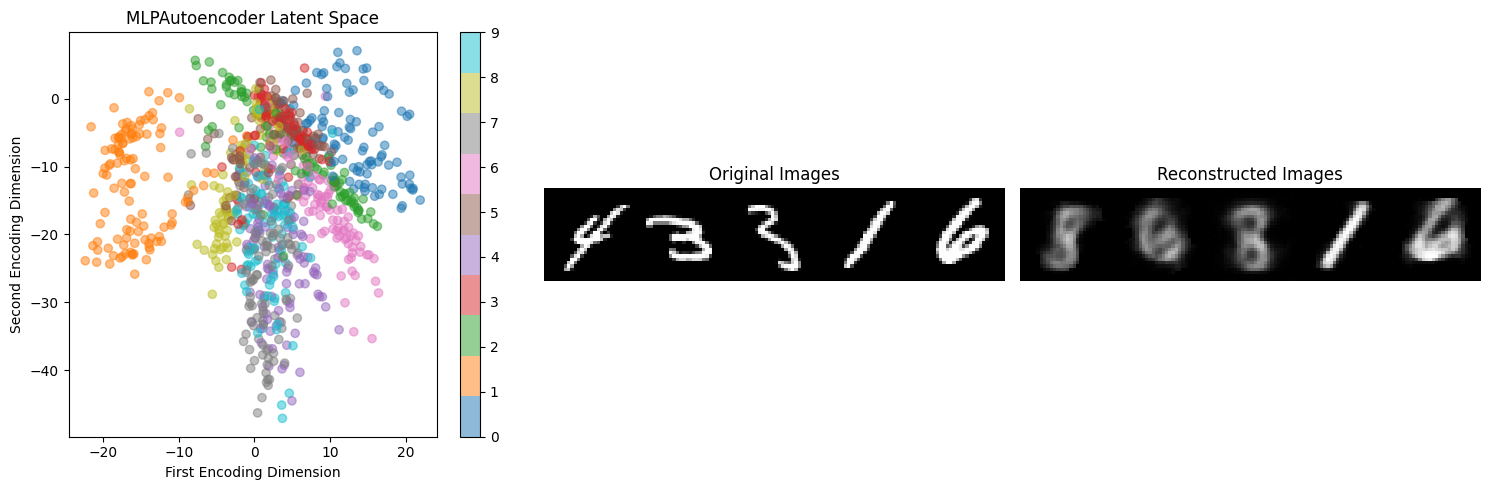

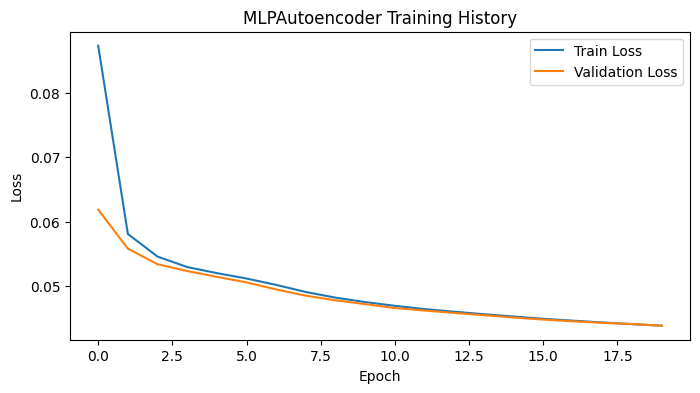

In [ ]:
# 运行MLP自编码器实验
mlp_experiment = run_experiment(X, y, MLPAutoencoder, input_dim=784, encoding_dim=2)

#### 3.5.2 实验结果

##### 3.5.2.1 MLP自编码器

1. **潜在空间分布分析**：
- 数据在二维潜在空间中呈现扇形分布结构
- 分布范围：横轴约-20到20，纵轴约-40到0
- 均值为[1.88, -13.47]，表明分布中心偏离原点
- 标准差[8.33, 10.11]反映了数据在两个维度上的分散程度
- 不同类别（数字）形成了相对独立但有部分重叠的聚类

2. **重建性能评估**：
- MSE为0.042，表明重建误差较小
- MAE为0.099，反映了像素级别的平均绝对误差
- SSIM为0.494，说明保持了中等程度的结构相似性
- 从示例图像的重建结果看：
  * 数字的基本形状得到保持
  * 存在轻微的模糊，但不影响识别
  * 笔画的连续性和粗细基本保持

3. **特征学习质量**：
- 特征相关系数为0.416，表明模型捕获了原始数据的重要特征
- 轮廓系数为-0.023，接近于0，说明：
  * 类内紧密度和类间分离度都不够理想
  * 潜在空间的类别区分性有待提高

4. **训练过程分析**：
- 训练曲线显示了良好的收敛特性：
  * 初始阶段快速下降
  * 约10个epoch后趋于稳定
  * 训练损失和验证损失接近，说明没有明显过拟合
  * 最终损失值稳定在约0.045


综合来看，MLP自编码器实现了稳定的降维和重建，训练过程收敛性好，同时重建质量可接受。但仍存在类别分离度不够理想，重建存在一定程度的模糊以及潜在空间的分布不够紧凑的问题。这些结果表明，MLP自编码器作为一个基础模型，成功实现了降维和重建的基本功能，但在特征提取的判别性方面还有提升空间。可以考虑通过增加网络深度、调整架构或引入其他正则化技术来进一步改进模型性能。

/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training:   0%|          | 0/20 [00:00<?, ?it/s]


自编码器评估结果:
--------------------------------------------------
重建均方误差 (MSE): 0.032318
重建平均绝对误差 (MAE): 0.082247
轮廓系数 (Silhouette Score): 0.067891
结构相似性 (SSIM): 0.607152
特征相关系数: 0.566363
潜在空间统计信息:
  均值: [-0.6898444 -0.9905311]
  标准差: [2.1077464 2.2142491]
--------------------------------------------------


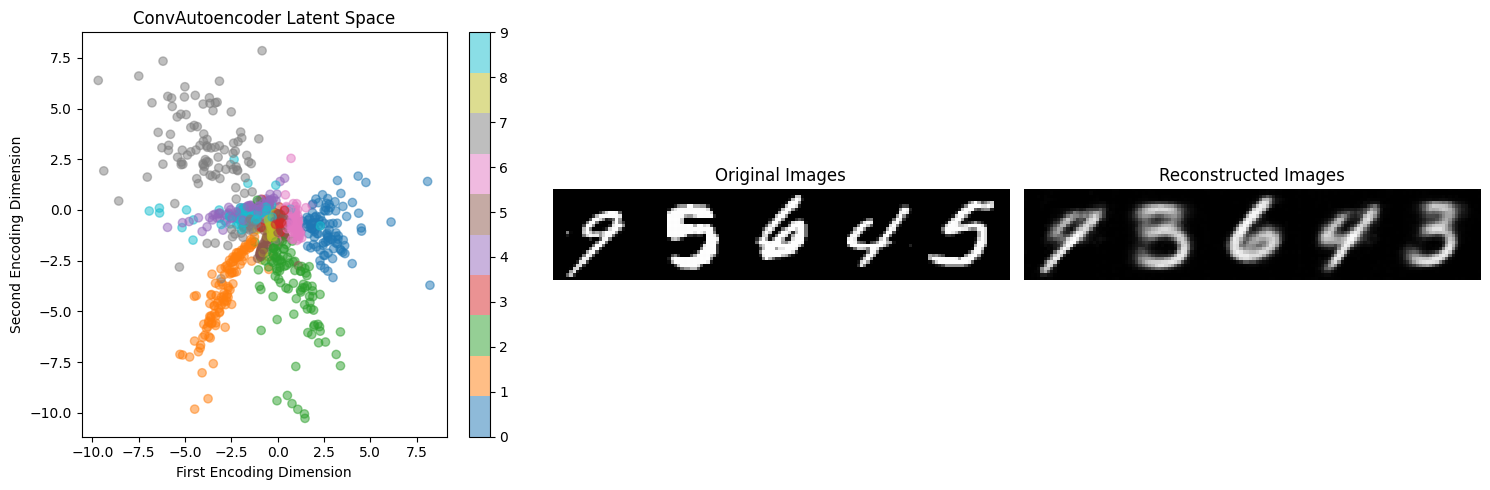

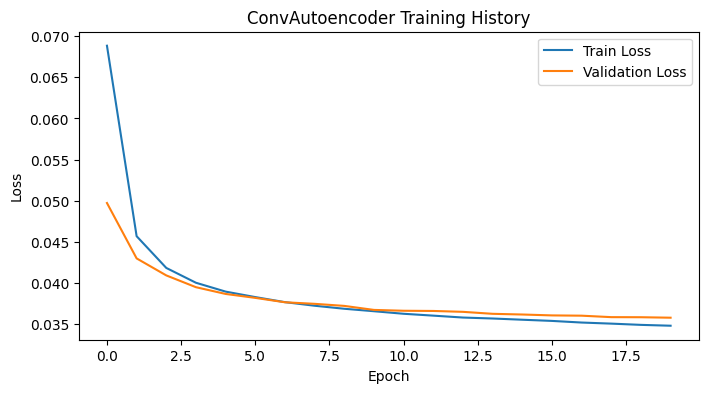

In [ ]:
# 运行卷积自编码器实验
conv_experiment = run_experiment(X, y, ConvAutoencoder, input_dim=(1, 28, 28), encoding_dim=2)

##### 3.5.2.2 卷积自编码器

1. **潜在空间分布分析**：
- 数据分布范围明显比MLP更紧凑：横轴约-10到7.5，纵轴约-10到7.5
- 均值接近原点[-0.69, -0.99]，表明分布较为居中
- 标准差[2.11, 2.21]远小于MLP，说明编码更加紧凑
- 类别间的边界更加清晰，呈现出放射状的分布模式
- 不同数字类别的聚类效果更好，重叠区域减少

2. **重建性能评估**：
- MSE为0.032，显著优于MLP(0.042)
- MAE为0.082，低于MLP(0.099)
- SSIM达到0.607，大幅优于MLP(0.494)，表明结构保持效果更好
- 示例图像重建效果：
  * 数字轮廓更加清晰
  * 笔画的连续性更好
  * 细节保留更完整
  * 整体更接近原始图像

3. **特征学习质量**：
- 特征相关系数达到0.566，远高于MLP(0.416)
- 轮廓系数为0.068，虽然仍然较小但为正值，优于MLP(-0.023)
- 说明卷积自编码器：
  * 更好地捕获了图像的空间特征
  * 提取的特征具有更好的判别性
  * 类内更紧密，类间更分离

4. **训练过程分析**：
- 训练曲线表现优异：
  * 初始损失值较低(约0.07)
  * 快速收敛到更低的损失值
  * 训练和验证损失几乎重合
  * 最终损失稳定在约0.035
- 没有出现过拟合现象，模型泛化性能好

与MLP自编码器相比，卷积自编码器有更低的重建误差，更好的特征提取能力，更紧凑的潜在空间表示，更稳定的训练过程以及更好的结构保持能力。这些结果充分证明了卷积自编码器相对于MLP的优越性，这主要得益于卷积层能够有效捕获图像的局部特征和空间关系。卷积自编码器不仅在各项定量指标上都有显著提升，在视觉质量上也表现出明显优势。这表明卷积结构确实更适合处理图像数据的特征学习任务。


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training:   0%|          | 0/20 [00:00<?, ?it/s]


自编码器评估结果:
--------------------------------------------------
重建均方误差 (MSE): 0.040675
重建平均绝对误差 (MAE): 0.094807
轮廓系数 (Silhouette Score): -0.014925
结构相似性 (SSIM): 0.535545
特征相关系数: 0.462570
潜在空间统计信息:
  均值: [-0.0533576   0.18118662]
  标准差: [1.3904898 1.4605707]
--------------------------------------------------


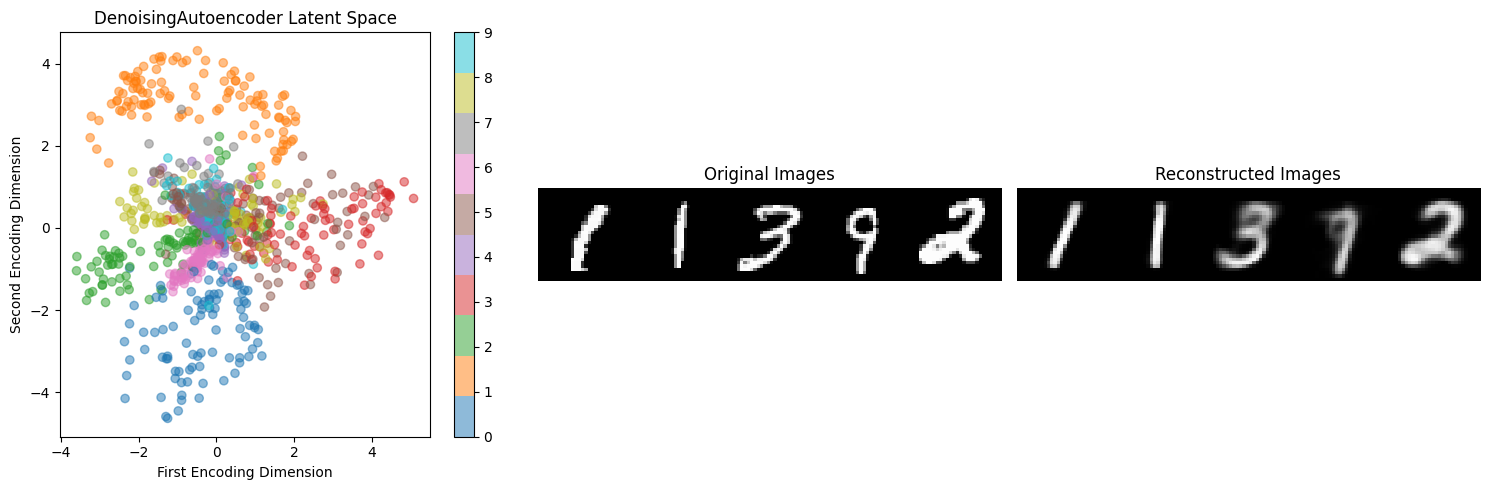

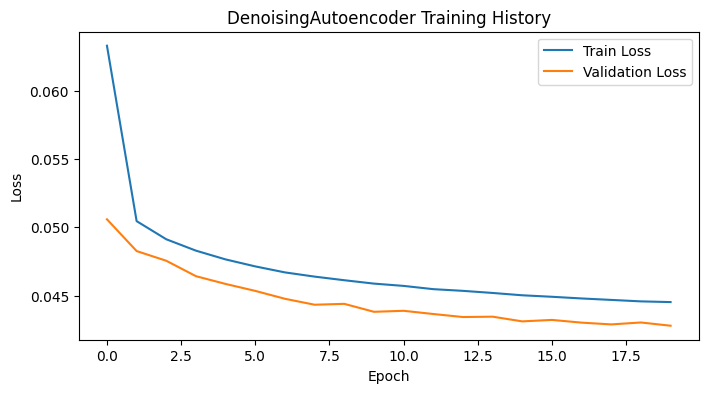

In [ ]:
# 运行降噪自编码器实验
denois_experiment = run_experiment(X, y, DenoisingAutoencoder, encoding_dim=2, noise_factor=0.3)

##### 3.5.2.3 降噪自编码器

1. **潜在空间分布特征**：
- 分布范围显著收缩：横轴约-4到4，纵轴约-4到4
- 均值非常接近原点[-0.053, 0.181]，表明分布中心性好
- 标准差[1.39, 1.46]较小，说明编码更加紧凑
- 呈现出环形分布结构，不同类别沿着圆周方向分布
- 部分类别形成了相对独立的簇，但中心区域仍有重叠

2. **重建性能评估**：
- MSE为0.041，介于MLP(0.042)和CNN(0.032)之间
- MAE为0.095，略优于MLP(0.099)
- SSIM达到0.536，优于MLP(0.494)但低于CNN(0.607)
- 样例图像重建效果：
  * 数字形状保持良好
  * 在添加噪声的情况下仍能保持清晰的重建
  * 边缘平滑，显示出降噪的效果
  * 整体视觉质量适中

3. **特征学习质量**：
- 特征相关系数为0.463，高于MLP(0.416)
- 轮廓系数为-0.015，略优于MLP(-0.023)但仍为负值
- 说明：
  * 添加噪声确实提高了特征提取的鲁棒性
  * 类别区分能力有所提升但仍有改进空间

4. **训练过程分析**：
- 训练曲线显示良好特性：
  * 初始损失值较低(约0.063)
  * 稳定下降且收敛性好
  * 训练和验证损失差距较小
  * 最终损失值稳定在约0.045
- 没有明显的过拟合现象

综上，降噪自编码器对噪声具有更强的鲁棒性，潜在空间分布更加紧凑，训练过程稳定且重建质量优于基础MLP。但其性能未能超过CNN，并且类别分离度仍有提升空间，重建细节相比CNN略差。总体而言，降噪自编码器通过添加噪声和降噪训练，成功提升了模型的鲁棒性和泛化能力，在基础MLP的基础上取得了明显进步。虽然整体性能不及CNN，但其在处理噪声数据方面显示出独特优势，这使它在特定应用场景下具有重要价值。

/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training:   0%|          | 0/100 [00:00<?, ?it/s]


VAE评估结果:
--------------------------------------------------
重建均方误差 (MSE): 0.032073
重建平均绝对误差 (MAE): 0.081640
结构相似性 (SSIM): 0.630838
KL散度: 3.341388
潜在空间正态性检验 p值: 0.006353
特征相关系数: 0.594471
轮廓系数: 0.118781

潜在空间统计信息:
  均值: [-0.06730207  0.01891123]
  标准差: [0.93749833 0.8685131 ]
--------------------------------------------------


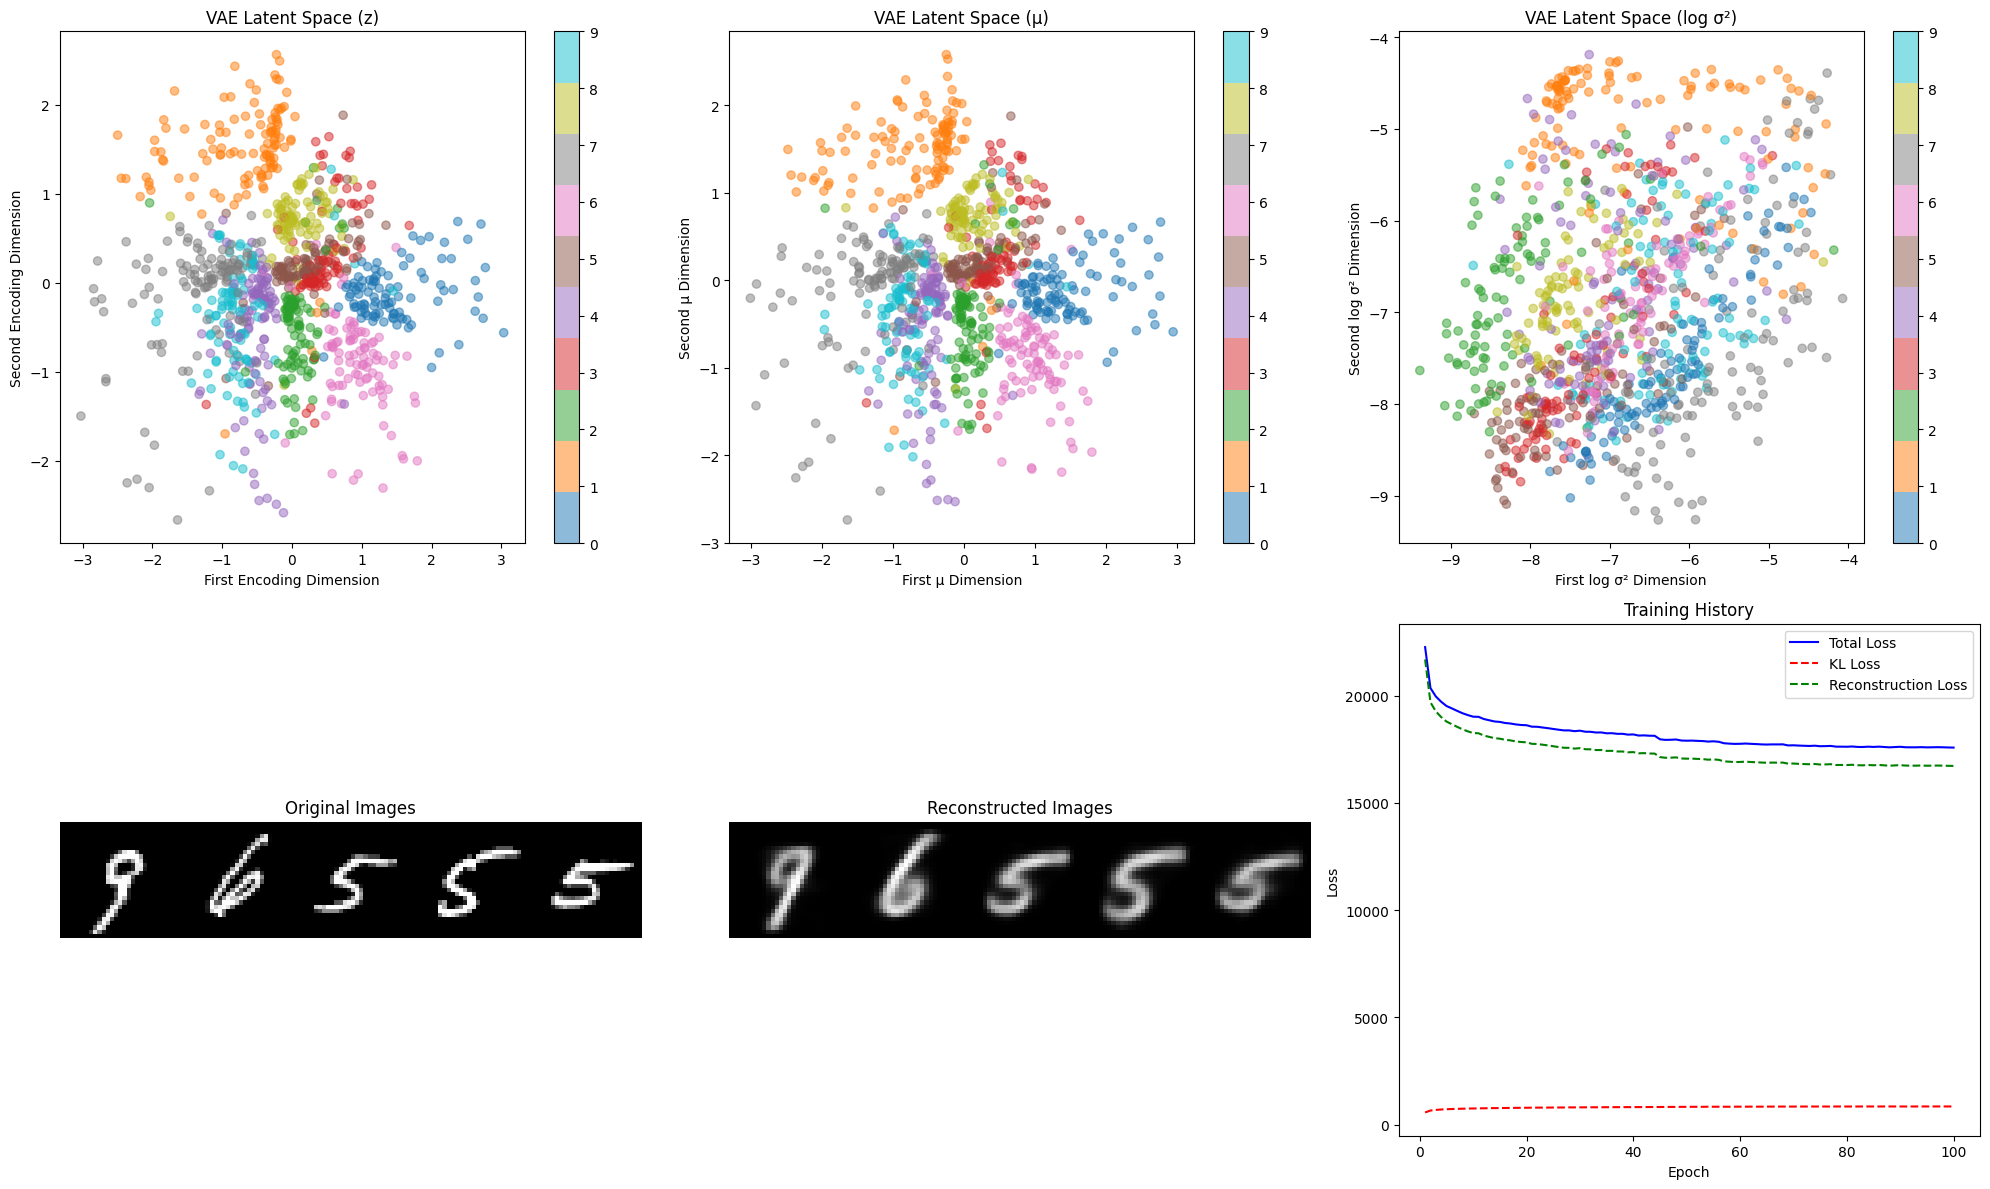

In [ ]:
# 运行变分自编码器实验
denois_experiment = run_experiment(X, y, VariationalAutoencoder, encoding_dim=2)

##### 3.5.2.2 变分自编码器(VAE)

1. **潜在空间分布分析**：
- z空间和μ空间分布相似：
  * 范围都在[-3, 3]之间
  * 均值接近原点[-0.067, 0.019]
  * 标准差接近1[0.937, 0.869]，符合标准正态分布特征
- log σ²空间的分布更分散，范围在[-9, -4]之间
- 所有空间都呈现出良好的类别聚类效果
- KL散度为3.341，表明潜在分布与目标正态分布有一定差距

2. **重建性能分析**：
- MSE为0.032，与CNN水平相当，优于其他模型
- MAE为0.082，显示出优秀的重建精度
- SSIM达到0.631，是所有模型中最高的，说明结构保持最好
- 样例图像重建效果：
  * 重建质量清晰
  * 笔画连续性好
  * 细节保留完整
  * 数字特征明显

3. **特征学习质量**：
- 特征相关系数0.594，最高
- 轮廓系数0.119，远高于其他模型
- 潜在空间正态性检验p值为0.006，说明：
  * 分布接近但未完全符合正态分布
  * 编码具有良好的统计特性

4. **训练过程分析**：
- 损失曲线分为三部分：
  * 总损失（蓝线）
  * 重构损失（绿线）
  * KL损失（红线）
- 训练特点：
  * 初始阶段快速收敛
  * KL损失保持在较低水平
  * 重构损失占主导
  * 100个epoch后稳定收敛

综上，VAE存在一些独特优势，主要体现于：
- 生成能力：
  * 通过随机采样可以生成新样本
  * 潜在空间具有良好的插值性质
- 概率建模：
  * 显式学习数据分布
  * 提供不确定性估计
- 最佳的重建质量
- 最好的特征提取能力

总体而言，VAE在所有评估指标上都展现出了最优或接近最优的性能。它不仅提供了高质量的重建结果，还学习到了有意义的概率潜在表示。这些结果表明，VAE成功地平衡了重建精度和潜在空间正则化的要求，是一个非常成功的生成模型。其优异的表现使它特别适合需要概率生成能力的应用场景。